# EDA 

## 1. Configurations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import os
from pathlib import Path
from urllib.parse import parse_qsl, urlsplit
import requests
from dotenv import load_dotenv, find_dotenv
from IPython.display import display

In [2]:
PROJECT_ROOT = Path.cwd()
load_dotenv(PROJECT_ROOT / ".env")


def require_secret(name: str) -> str:
    """Return a configured secret without printing or storing it in the notebook."""
    value = os.getenv(name)
    if not value:
        raise RuntimeError(
            f"{name} is not configured. Add it to the project-root .env file."
        )
    return value

## 2. Data Loader

### 2.1 Massive

- **Treasury Yields:** Daily frequency; 3-month, 2-year, and 10-year Treasury yields, with the 10-year–3-month spread derived as `T10Y3M`.
- **Inflation Expectations:** Monthly frequency; 10-year breakeven inflation, 5-year/5-year forward inflation, and Cleveland Fed model-based expectations.
- **Labor Market:** Monthly frequency; unemployment rate, labor-force participation, average hourly earnings, and job openings.
- **Funding Conditions:** Daily frequency; effective federal funds rate, SOFR, policy-rate bounds, repo activity, commercial-paper rates, and overnight funding volumes.
- **Realized Inflation:** Monthly frequency; headline and core CPI/PCE indexes, PCE spending, and derived realized month-over-month inflation rates.
- **Timing Note:** Monthly timestamps represent observation periods and will require release-date alignment before entering the weekly model.

In [3]:
# Paste after the configuration cell in Data_Engineering_v2.ipynb.

MASSIVE_ECONOMY_ENDPOINTS = {
    "treasury": "treasury-yields",
    "inflation": "inflation",
    "expectations": "inflation-expectations",
    "labor": "labor-market",
    "funding": "funding-conditions",
}


def load_massive_economy(
    endpoint: str,
    start_date: str | None = None,
    end_date: str | None = None,
) -> pd.DataFrame:
    if endpoint not in MASSIVE_ECONOMY_ENDPOINTS.values():
        raise ValueError(f"Unsupported Massive Economy endpoint: {endpoint}")

    api_key = require_secret("MASSIVE_API_KEY")
    url = f"https://api.massive.com/fed/v1/{endpoint}"

    params = {
        "apiKey": api_key,
        "limit": 50_000,
        "sort": "date.asc",
    }

    if start_date is not None:
        params["date.gte"] = start_date

    if end_date is not None:
        params["date.lte"] = end_date

    rows = []
    first_request = True

    with requests.Session() as session:
        while url:
            if first_request:
                request_params = params
                first_request = False
            else:
                query_keys = {
                    key for key, _ in parse_qsl(urlsplit(url).query)
                }
                request_params = (
                    None if "apiKey" in query_keys
                    else {"apiKey": api_key}
                )

            try:
                response = session.get(
                    url,
                    params=request_params,
                    timeout=30,
                )
            except requests.RequestException:
                raise RuntimeError(
                    f"Massive request failed for {endpoint}"
                ) from None

            if not response.ok:
                raise RuntimeError(
                    f"Massive returned HTTP {response.status_code} "
                    f"for {endpoint}"
                )

            try:
                payload = response.json()
            except requests.JSONDecodeError:
                raise RuntimeError(
                    f"Massive returned invalid JSON for {endpoint}"
                ) from None

            rows.extend(payload.get("results", []))
            url = payload.get("next_url")

    if not rows:
        return pd.DataFrame(index=pd.DatetimeIndex([], name="date"))

    frame = pd.DataFrame(rows)

    if "date" not in frame.columns:
        raise RuntimeError(
            f"Massive response for {endpoint} has no date field"
        )

    frame["date"] = pd.to_datetime(frame["date"], errors="coerce")

    for column in frame.columns.difference(["date"]):
        frame[column] = pd.to_numeric(frame[column], errors="coerce")

    return (
        frame.dropna(subset=["date"])
        .drop_duplicates(subset=["date"], keep="last")
        .set_index("date")
        .sort_index()
    )


START_DATE = "2004-01-01"
END_DATE = pd.Timestamp.today().normalize().strftime("%Y-%m-%d")

massive_treasury_raw = load_massive_economy(
    "treasury-yields",
    START_DATE,
    END_DATE,
)

massive_expectations_raw = load_massive_economy(
    "inflation-expectations",
    START_DATE,
    END_DATE,
)

massive_labor_raw = load_massive_economy(
    "labor-market",
    START_DATE,
    END_DATE,
)

massive_funding_raw = load_massive_economy(
    "funding-conditions",
    START_DATE,
    END_DATE,
)

massive_inflation_raw = load_massive_economy(
    "inflation",
    START_DATE,
    END_DATE,
)


massive_rates_daily = (
    massive_treasury_raw[
        ["yield_3_month", "yield_2_year", "yield_10_year"]
    ]
    .rename(
        columns={
            "yield_3_month": "ust_3m",
            "yield_2_year": "ust_2y",
            "yield_10_year": "ust_10y",
        }
    )
    .copy()
)

massive_rates_daily["T10Y3M"] = (
    massive_rates_daily["ust_10y"]
    - massive_rates_daily["ust_3m"]
)


massive_expectations_monthly = (
    massive_expectations_raw.rename(
        columns={
            "market_10_year": "T10YIE",
            "forward_years_5_to_10": "infl_5y5y",
        }
    )
    .copy()
)


massive_labor_monthly = (
    massive_labor_raw.rename(
        columns={
            "unemployment_rate": "unrate",
        }
    )
    .copy()
)


massive_funding_daily = (
    massive_funding_raw.rename(
        columns={
            "effective_fed_funds_rate": "fedfunds",
            "secured_overnight_financing_rate": "SOFR",
        }
    )
    .copy()
)


massive_inflation_monthly = (
    massive_inflation_raw.rename(
        columns={
            "cpi": "cpi_index",
            "cpi_core": "core_cpi_index",
            "pce": "pce_index",
            "pce_core": "core_pce_index",
        }
    )
    .copy()
)

massive_inflation_monthly["cpi_mom_realized"] = (
    massive_inflation_monthly["cpi_index"]
    .pct_change(fill_method=None)
    .mul(100)
)

massive_inflation_monthly["core_cpi_mom_realized"] = (
    massive_inflation_monthly["core_cpi_index"]
    .pct_change(fill_method=None)
    .mul(100)
)

massive_inflation_monthly["pce_mom_realized"] = (
    massive_inflation_monthly["pce_index"]
    .pct_change(fill_method=None)
    .mul(100)
)

massive_inflation_monthly["core_pce_mom_realized"] = (
    massive_inflation_monthly["core_pce_index"]
    .pct_change(fill_method=None)
    .mul(100)
)


massive_datasets = {
    "treasury_daily": massive_rates_daily,
    "expectations_monthly": massive_expectations_monthly,
    "labor_monthly": massive_labor_monthly,
    "funding_daily": massive_funding_daily,
    "inflation_monthly": massive_inflation_monthly,
}

massive_coverage = pd.DataFrame(
    {
        name: {
            "rows": len(frame),
            "start": frame.index.min(),
            "end": frame.index.max(),
            "columns": ", ".join(frame.columns),
        }
        for name, frame in massive_datasets.items()
    }
).T

massive_coverage

,rows,start,end,columns
treasury_daily,5675,2004-01-02 00:00:00,2026-09-08 00:00:00,"ust_3m, ust_2y, ust_10y, T10Y3M"
expectations_monthly,272,2004-01-01 00:00:00,2026-08-01 00:00:00,"market_5_year, T10YIE, infl_5y5y, model_1_year..."
labor_monthly,272,2004-01-01 00:00:00,2026-08-01 00:00:00,"unrate, labor_force_participation_rate, job_op..."
funding_daily,8289,2004-01-01 00:00:00,2026-09-10 00:00:00,"fedfunds, fed_overnight_repo_treasury_amount, ..."
inflation_monthly,271,2004-01-01 00:00:00,2026-07-01 00:00:00,"cpi_index, cpi_year_over_year, core_cpi_index,..."


### 2.2 FRED

- **Initial Unemployment Claims (`ICSA`):** Weekly frequency; high-frequency indicator of labor-market deterioration.
- **Unemployment Rate (`UNRATE`):** Monthly frequency; retained for point-in-time comparison with Massive labor data.
- **Real-Time Sahm Rule (`SAHMREALTIME`):** Monthly frequency; recession indicator based on changes in unemployment.
- **10-Year Breakeven Inflation (`T10YIE`):** Daily frequency; market-implied long-term inflation expectations.
- **10-Year Real Yield (`DFII10`):** Daily frequency; inflation-adjusted Treasury yield and measure of real-rate pressure.
- **5-Year/5-Year Forward Inflation (`T5YIFR`):** Daily frequency; long-term forward inflation expectations.
- **Financial Conditions (`NFCI`, `ANFCI`):** Weekly frequency; broad and adjusted measures of U.S. financial conditions.
- **High-Yield Credit Spread (`BAMLH0A0HYM2`):** Daily frequency; option-adjusted spread for U.S. high-yield corporate bonds.
- **Economic Policy Uncertainty (`USEPUINDXD`):** Daily frequency; news-based measure of U.S. policy uncertainty.
- **WTI Crude Oil (`DCOILWTICO`):** Daily frequency; spot oil price used in the inflation-shock bucket.
- **Broad U.S. Dollar Index (`DTWEXBGS`):** Daily frequency; trade-weighted dollar measure used in the financial-stress bucket.
- **Vintage Note:** The current dataset is loaded as an ALFRED/FRED snapshot using the configured `FRED_VINTAGE_DATE`.

In [4]:
FRED_SERIES = {
    # Growth and labor
    "ICSA": "ICSA",
    "unrate": "UNRATE",
    "sahm_realtime": "SAHMREALTIME",

    # Rates and inflation expectations
    # Retained because FRED provides higher-frequency observations than Massive.
    "T10YIE": "T10YIE",
    "DFII10": "DFII10",
    "infl_5y5y": "T5YIFR",

    # Financial conditions and stress
    "NFCI": "NFCI",
    "ANFCI": "ANFCI",
    "HY_OAS": "BAMLH0A0HYM2",
    "EPU": "USEPUINDXD",

    # Commodity and currency
    "oil_wti": "DCOILWTICO",
    "usd_broad": "DTWEXBGS",
}


def load_fred_series(
    series_id: str,
    start_date: str | None = None,
    end_date: str | None = None,
    vintage_date: str | None = None,
) -> pd.Series:
    api_key = require_secret("FRED_API_KEY")
    url = "https://api.stlouisfed.org/fred/series/observations"

    params = {
        "series_id": series_id,
        "api_key": api_key,
        "file_type": "json",
        "sort_order": "asc",
        "limit": 100_000,
        "offset": 0,
    }

    if start_date is not None:
        params["observation_start"] = start_date

    if end_date is not None:
        params["observation_end"] = end_date

    if vintage_date is not None:
        params["realtime_start"] = vintage_date
        params["realtime_end"] = vintage_date

    observations = []

    with requests.Session() as session:
        while True:
            try:
                response = session.get(
                    url,
                    params=params,
                    timeout=30,
                )
            except requests.RequestException:
                raise RuntimeError(
                    f"FRED request failed for {series_id}"
                ) from None

            if not response.ok:
                raise RuntimeError(
                    f"FRED returned HTTP {response.status_code} "
                    f"for {series_id}"
                )

            try:
                payload = response.json()
            except requests.JSONDecodeError:
                raise RuntimeError(
                    f"FRED returned invalid JSON for {series_id}"
                ) from None

            batch = payload.get("observations", [])
            observations.extend(batch)

            count = int(payload.get("count", len(observations)))
            offset = int(payload.get("offset", params["offset"]))
            limit = int(payload.get("limit", params["limit"]))

            if offset + limit >= count:
                break

            params["offset"] = offset + limit

    if not observations:
        return pd.Series(
            dtype="float64",
            name=series_id,
            index=pd.DatetimeIndex([], name="date"),
        )

    frame = pd.DataFrame(observations)

    frame["date"] = pd.to_datetime(
        frame["date"],
        errors="coerce",
    )

    frame["value"] = pd.to_numeric(
        frame["value"],
        errors="coerce",
    )

    series = (
        frame.dropna(subset=["date"])
        .drop_duplicates(subset=["date"], keep="last")
        .set_index("date")["value"]
        .sort_index()
    )

    series.name = series_id
    return series


def load_fred_panel(
    series_map: dict[str, str],
    start_date: str | None = None,
    end_date: str | None = None,
    vintage_date: str | None = None,
) -> pd.DataFrame:
    series = {
        model_name: load_fred_series(
            series_id=series_id,
            start_date=start_date,
            end_date=end_date,
            vintage_date=vintage_date,
        )
        for model_name, series_id in series_map.items()
    }

    panel = pd.concat(series, axis=1).sort_index()
    panel.index.name = "date"

    return panel


FRED_START_DATE = "2004-01-01"
FRED_END_DATE = pd.Timestamp.today().normalize().strftime("%Y-%m-%d")
FRED_VINTAGE_DATE = FRED_END_DATE

fred_raw = load_fred_panel(
    series_map=FRED_SERIES,
    start_date=FRED_START_DATE,
    end_date=FRED_END_DATE,
    vintage_date=FRED_VINTAGE_DATE,
)


fred_coverage = pd.DataFrame(
    {
        column: {
            "fred_series": FRED_SERIES[column],
            "observations": fred_raw[column].notna().sum(),
            "first_valid": fred_raw[column].first_valid_index(),
            "last_valid": fred_raw[column].last_valid_index(),
        }
        for column in fred_raw.columns
    }
).T

fred_coverage

,fred_series,observations,first_valid,last_valid
ICSA,ICSA,1184,2004-01-03 00:00:00,2026-09-05 00:00:00
unrate,UNRATE,271,2004-01-01 00:00:00,2026-08-01 00:00:00
sahm_realtime,SAHMREALTIME,271,2004-01-01 00:00:00,2026-08-01 00:00:00
T10YIE,T10YIE,5676,2004-01-02 00:00:00,2026-09-09 00:00:00
DFII10,DFII10,5676,2004-01-02 00:00:00,2026-09-09 00:00:00
infl_5y5y,T5YIFR,5676,2004-01-02 00:00:00,2026-09-09 00:00:00
NFCI,NFCI,1184,2004-01-02 00:00:00,2026-09-04 00:00:00
ANFCI,ANFCI,1184,2004-01-02 00:00:00,2026-09-04 00:00:00
HY_OAS,BAMLH0A0HYM2,787,2023-09-11 00:00:00,2026-09-09 00:00:00
EPU,USEPUINDXD,8288,2004-01-01 00:00:00,2026-09-09 00:00:00


### 2.3 CBOE VIX

In [5]:
CBOE_VIX_URL = (
    "https://cdn.cboe.com/api/global/us_indices/"
    "daily_prices/VIX_History.csv"
)

vix_raw = pd.read_csv(CBOE_VIX_URL, parse_dates=["DATE"])

vix = (
    vix_raw
    .rename(columns={"DATE": "date", "CLOSE": "VIX"})
    .set_index("date")["VIX"]
    .sort_index()
)

### 2.4 Cleveland Inflation Nowcasts

In [6]:
INFLATION_NOWCAST_DIR = (
    Path.home()
    / "Desktop"
    / "Data"
    / "Macro"
    / "Inflation_Nowcast"
)

INFLATION_NOWCAST_COLUMNS = {
    "CPI Inflation": "cpi_inflation_mom",
    "Core CPI Inflation": "core_cpi_inflation_mom",
    "PCE Inflation": "pce_inflation_mom",
    "Core PCE Inflation": "core_pce_inflation_mom",
}

INFLATION_VALUE_COLUMNS = list(
    INFLATION_NOWCAST_COLUMNS.values()
)


def parse_target_month(file_path: Path) -> pd.Timestamp:
    pattern = (
        r"Month-Over-MonthPercentChange-"
        r"(\d{4})-(\d{1,2})\.csv"
    )

    match = re.fullmatch(pattern, file_path.name)

    if match is None:
        raise ValueError(
            f"Invalid inflation-nowcast filename: {file_path.name}"
        )

    year = int(match.group(1))
    month = int(match.group(2))

    return pd.Timestamp(year=year, month=month, day=1)


def parse_forecast_dates(
    labels: pd.Series,
    starting_year: int,
) -> pd.DatetimeIndex:
    dates = []
    current_year = starting_year
    previous_month = None

    for label in labels:
        month, day = map(
            int,
            str(label).strip().split("/"),
        )

        if (
            previous_month is not None
            and month < previous_month
        ):
            current_year += 1

        dates.append(
            pd.Timestamp(
                year=current_year,
                month=month,
                day=day,
            )
        )

        previous_month = month

    index = pd.DatetimeIndex(dates)

    if not index.is_monotonic_increasing:
        raise ValueError(
            "Forecast dates are not chronologically ordered."
        )

    return index


def read_inflation_nowcast_file(
    file_path: Path,
) -> pd.DataFrame:
    target_month = parse_target_month(file_path)

    frame = pd.read_csv(file_path)
    frame.columns = frame.columns.str.strip()

    required_columns = [
        "Label",
        *INFLATION_NOWCAST_COLUMNS,
    ]

    missing_columns = [
        column
        for column in required_columns
        if column not in frame.columns
    ]

    if missing_columns:
        raise ValueError(
            f"{file_path.name} is missing columns: "
            f"{missing_columns}"
        )

    frame = frame[required_columns].rename(
        columns=INFLATION_NOWCAST_COLUMNS
    )

    frame["forecast_date"] = parse_forecast_dates(
        frame["Label"],
        starting_year=target_month.year,
    )

    frame["target_month"] = target_month

    for column in INFLATION_VALUE_COLUMNS:
        frame[column] = pd.to_numeric(
            frame[column],
            errors="coerce",
        )

    return frame[
        [
            "forecast_date",
            "target_month",
            *INFLATION_VALUE_COLUMNS,
        ]
    ]


def load_inflation_nowcasts(
    folder: Path,
) -> pd.DataFrame:
    files = list(
        folder.glob(
            "Month-Over-MonthPercentChange-*.csv"
        )
    )

    if not files:
        raise FileNotFoundError(
            f"No inflation-nowcast files found in {folder}"
        )

    files = sorted(
        files,
        key=lambda path: parse_target_month(path),
    )

    frames = [
        read_inflation_nowcast_file(file_path)
        for file_path in files
    ]

    combined = (
        pd.concat(frames, ignore_index=True)
        .sort_values(
            ["forecast_date", "target_month"]
        )
    )

    duplicate_pairs = combined.duplicated(
        ["forecast_date", "target_month"]
    )

    if duplicate_pairs.any():
        raise ValueError(
            "Duplicate forecast-date and target-month pairs found."
        )

    return combined.set_index(
        ["forecast_date", "target_month"]
    ).sort_index()


def select_front_inflation_nowcast(
    nowcast_long: pd.DataFrame,
) -> pd.DataFrame:
    """
    For each forecast date and inflation measure, select the
    earliest target month that still has a published nowcast.
    """

    frame = (
        nowcast_long.reset_index()
        .sort_values(
            ["forecast_date", "target_month"]
        )
    )

    selected = {}

    for column in INFLATION_VALUE_COLUMNS:
        selected[column] = (
            frame.dropna(subset=[column])
            .groupby("forecast_date", sort=True)[column]
            .first()
        )

    output = pd.DataFrame(selected).sort_index()
    output.index.name = "forecast_date"

    return output


inflation_nowcast_long = load_inflation_nowcasts(
    INFLATION_NOWCAST_DIR
)

infl_nowcast_daily = select_front_inflation_nowcast(
    inflation_nowcast_long
)


inflation_nowcast_coverage = pd.Series(
    {
        "files_loaded": (
            inflation_nowcast_long
            .index
            .get_level_values("target_month")
            .nunique()
        ),
        "long_rows": len(inflation_nowcast_long),
        "daily_rows": len(infl_nowcast_daily),
        "first_forecast_date": (
            infl_nowcast_daily.index.min()
        ),
        "last_forecast_date": (
            infl_nowcast_daily.index.max()
        ),
        "first_target_month": (
            inflation_nowcast_long
            .index
            .get_level_values("target_month")
            .min()
        ),
        "last_target_month": (
            inflation_nowcast_long
            .index
            .get_level_values("target_month")
            .max()
        ),
    },
    name="Cleveland Fed inflation nowcasts",
)

display(inflation_nowcast_coverage)
display(infl_nowcast_daily.tail())

files_loaded                           159
long_rows                             6567
daily_rows                            3276
first_forecast_date    2013-08-20 00:00:00
last_forecast_date     2026-09-09 00:00:00
first_target_month     2013-07-01 00:00:00
last_target_month      2026-09-01 00:00:00
Name: Cleveland Fed inflation nowcasts, dtype: object

,cpi_inflation_mom,core_cpi_inflation_mom,pce_inflation_mom,core_pce_inflation_mom
forecast_date,,,,
2026-09-02,0.359181,0.203342,0.353657,0.274535
2026-09-03,0.359181,0.203342,0.353657,0.274535
2026-09-04,0.359181,0.203342,0.353657,0.274535
2026-09-08,0.359181,0.203342,0.353657,0.274535
2026-09-09,0.359181,0.203342,0.353657,0.274535


### 2.5 Tiingo ETF Data

In [7]:
load_dotenv(find_dotenv(usecwd=True))

TIINGO_API_KEY = os.getenv("TIINGO_API_KEY")
if not TIINGO_API_KEY:
    raise RuntimeError("TIINGO_API_KEY is missing from .env")

ETF_TICKERS = ["SPY", "IEF", "TLT", "LQD", "HYG", "TIP"]
ETF_START_DATE = "2004-01-01"
ETF_END_DATE = pd.Timestamp.now(tz="UTC").strftime("%Y-%m-%d")

session = requests.Session()
session.headers.update({
    "Authorization": f"Token {TIINGO_API_KEY}",
    "Content-Type": "application/json",
})


def load_tiingo_etf(ticker, start_date=ETF_START_DATE, end_date=ETF_END_DATE):
    url = f"https://api.tiingo.com/tiingo/daily/{ticker}/prices"

    response = session.get(
        url,
        params={
            "startDate": start_date,
            "endDate": end_date,
            "resampleFreq": "daily",
            "format": "json",
        },
        timeout=30,
    )

    if response.status_code != 200:
        try:
            error_message = response.json()
        except ValueError:
            error_message = response.text[:300]

        raise RuntimeError(
            f"{ticker}: HTTP {response.status_code} — {error_message}"
        )

    data = response.json()
    if not data:
        raise RuntimeError(f"{ticker}: Tiingo returned no observations")

    df = pd.DataFrame(data)

    df["date"] = (
        pd.to_datetime(df["date"], utc=True)
        .dt.tz_localize(None)
        .dt.normalize()
    )

    df = df.rename(columns={
        "adjOpen": "adj_open",
        "adjHigh": "adj_high",
        "adjLow": "adj_low",
        "adjClose": "adj_close",
        "adjVolume": "adj_volume",
        "divCash": "div_cash",
        "splitFactor": "split_factor",
    })

    columns = [
        "date",
        "open",
        "high",
        "low",
        "close",
        "volume",
        "adj_open",
        "adj_high",
        "adj_low",
        "adj_close",
        "adj_volume",
        "div_cash",
        "split_factor",
    ]

    df = df.reindex(columns=columns)
    df.insert(1, "ticker", ticker)

    return df.sort_values("date").drop_duplicates("date", keep="last")


loaded_etfs = []
access_results = []

for ticker in ETF_TICKERS:
    try:
        ticker_data = load_tiingo_etf(ticker)
        loaded_etfs.append(ticker_data)

        access_results.append({
            "ticker": ticker,
            "accessible": True,
            "first_date": ticker_data["date"].min(),
            "last_date": ticker_data["date"].max(),
            "observations": len(ticker_data),
            "error": None,
        })

    except Exception as exc:
        access_results.append({
            "ticker": ticker,
            "accessible": False,
            "first_date": pd.NaT,
            "last_date": pd.NaT,
            "observations": 0,
            "error": str(exc),
        })

tiingo_access_report = pd.DataFrame(access_results).set_index("ticker")
display(tiingo_access_report)

if not loaded_etfs:
    raise RuntimeError("The Tiingo free plan did not return data for any requested ETF")

tiingo_etf_daily = (
    pd.concat(loaded_etfs, ignore_index=True)
    .set_index(["date", "ticker"])
    .sort_index()
)

# Dividend- and split-adjusted prices for return calculations
etf_prices = (
    tiingo_etf_daily["adj_close"]
    .unstack("ticker")
    .reindex(columns=ETF_TICKERS)
    .sort_index()
)

# Unadjusted closes and corporate actions retained for auditing
etf_close_raw = (
    tiingo_etf_daily["close"]
    .unstack("ticker")
    .reindex(columns=ETF_TICKERS)
)

etf_dividends = (
    tiingo_etf_daily["div_cash"]
    .unstack("ticker")
    .reindex(columns=ETF_TICKERS)
)

etf_split_factors = (
    tiingo_etf_daily["split_factor"]
    .unstack("ticker")
    .reindex(columns=ETF_TICKERS)
)

# Weekly adjusted prices and total returns
etf_prices_weekly = etf_prices.resample("W-FRI").last()
etf_returns_daily = etf_prices.pct_change(fill_method=None)
etf_returns_weekly = etf_prices_weekly.pct_change(fill_method=None)

if tiingo_access_report["accessible"].all():
    print("Tiingo free-plan access confirmed for all requested ETFs.")
else:
    unavailable = tiingo_access_report.index[
        ~tiingo_access_report["accessible"]
    ].tolist()
    print(f"Unavailable tickers: {unavailable}")

display(etf_prices.tail())
display(etf_returns_weekly.tail())

,accessible,first_date,last_date,observations,error
ticker,,,,,
SPY,True,2004-01-02,2026-09-09,5707,None
IEF,True,2004-01-02,2026-09-09,5707,None
TLT,True,2004-01-02,2026-09-09,5707,None
LQD,True,2004-01-02,2026-09-09,5707,None
HYG,True,2007-04-11,2026-09-09,4885,None
TIP,True,2004-01-02,2026-09-09,5707,None


Tiingo free-plan access confirmed for all requested ETFs.


ticker,SPY,IEF,TLT,LQD,HYG,TIP
date,,,,,,
2026-09-02,765.16,92.180,81.95,105.35,79.11,106.86
2026-09-03,773.17,92.280,82.07,105.50,79.21,107.00
2026-09-04,770.19,92.250,82.21,105.48,79.16,106.97
2026-09-08,765.96,92.160,82.20,105.48,79.12,107.05
2026-09-09,762.40,91.895,81.73,105.31,78.98,106.80


ticker,SPY,IEF,TLT,LQD,HYG,TIP
date,,,,,,
2026-08-14,0.003983,-0.001395,-0.008700,-0.004036,0.001256,-0.000840
2026-08-21,-0.013680,-0.002365,0.000122,-0.001885,-0.001255,0.001309
2026-08-28,0.004741,0.000323,0.010116,0.004060,0.001633,-0.001774
2026-09-04,0.001092,-0.002880,-0.004271,-0.003998,-0.001814,0.000281
2026-09-11,-0.010114,-0.003848,-0.005839,-0.001612,-0.002274,-0.001589


In [8]:
INDPRO_PATH = Path.home() / "Desktop" / "INDPRO.csv"

# Rows = observation months; columns = historical vintage dates.
indpro_vintages = pd.read_csv(
    INDPRO_PATH,
    index_col="observation_date",
    parse_dates=["observation_date"],
    na_values=["."],
)

if not indpro_vintages.columns.str.fullmatch(r"INDPRO_\d{8}").all():
    raise ValueError("Unexpected INDPRO CSV columns.")

indpro_vintages.columns = pd.DatetimeIndex(
    pd.to_datetime(
        indpro_vintages.columns.str.replace("INDPRO_", "", regex=False),
        format="%Y%m%d",
    ),
    name="vintage_date",
)

if (
    indpro_vintages.index.has_duplicates
    or indpro_vintages.columns.has_duplicates
):
    raise ValueError("Duplicate observation dates or vintage dates.")

indpro_vintages = (
    indpro_vintages
    .apply(pd.to_numeric, errors="raise")
    .sort_index()
    .sort_index(axis=1)
    .asfreq("MS")
)
indpro_vintages.index.name = "observation_date"

# Long format for revision analysis and joining with release metadata.
indpro_long = (
    indpro_vintages
    .reset_index()
    .melt(
        id_vars="observation_date",
        var_name="vintage_date",
        value_name="INDPRO",
    )
    .dropna(subset=["INDPRO"])
)

indpro_long["vintage_date"] = pd.to_datetime(indpro_long["vintage_date"])
indpro_long = (
    indpro_long
    .set_index(["vintage_date", "observation_date"])
    .sort_index()
)


def indpro_asof(as_of):
    """Retrieve the latest downloaded vintage on/before a YYYY-MM-DD date.

    Date-level snapshot: assumes the vintage is available by that day's end.
    Calculate growth rates within this snapshot, before weekly alignment.
    """
    cutoff = pd.Timestamp(as_of)
    eligible = indpro_vintages.columns[
        indpro_vintages.columns <= cutoff
    ]

    if len(eligible) == 0:
        raise ValueError(f"No vintage available on/before {cutoff.date()}.")

    vintage = eligible[-1]
    series = indpro_vintages[vintage]
    last_observation = series.last_valid_index()

    if last_observation is None:
        raise ValueError(
            "This vintage has no observations in the downloaded date range."
        )

    # Preserve any internal missing months; exclude unreleased future months.
    snapshot = series.loc[:last_observation].to_frame("INDPRO")
    snapshot.attrs["vintage_date"] = vintage

    return snapshot


# Latest downloaded snapshot: suitable for retrospective EDA.
indpro_latest_vintage = indpro_vintages.columns.max()
indpro_monthly = indpro_asof(indpro_latest_vintage)

# Historical example: selects the 2020-02-14 vintage.
indpro_snapshot_example = indpro_asof("2020-03-01")

print(
    f"{len(indpro_monthly)} observation months | "
    f"{indpro_vintages.shape[1]} vintages | "
    f"Latest vintage: {indpro_latest_vintage.date()}"
)

display(indpro_monthly.tail())
display(indpro_snapshot_example.tail())

151 observation months | 162 vintages | Latest vintage: 2026-08-18


,INDPRO
observation_date,
2026-03-01,101.7543
2026-04-01,102.5198
2026-05-01,102.5099
2026-06-01,102.7868
2026-07-01,102.9939


,INDPRO
observation_date,
2019-09-01,109.4800
2019-10-01,109.0086
2019-11-01,109.9726
2019-12-01,109.5407
2020-01-01,109.2026


## 3. Statistical Exploration

### 3.1 Hypothesis 1: Do claims add info about upcoming production growth?

In [9]:
# 1. Retrieve claim revisions

import statsmodels.api as sm
from scipy.stats import norm

load_dotenv(find_dotenv(usecwd=True))


def load_claims_vintage_history(observation_start, as_of_end):
    key = os.getenv("FRED_API_KEY")
    if not key:
        raise RuntimeError("FRED_API_KEY is missing from the environment.")

    params = {
        "api_key": key,
        "file_type": "json",
        "series_id": "ICSA",
        "observation_start": observation_start,
        "observation_end": as_of_end,
        "realtime_start": observation_start,
        "realtime_end": as_of_end,
        "output_type": 1,
        "limit": 100000,
        "offset": 0,
    }

    records = []

    with requests.Session() as session:
        while True:
            try:
                response = session.get(
                    "https://api.stlouisfed.org/fred/series/observations",
                    params=params,
                    timeout=60,
                )
            except requests.RequestException:
                # Avoid printing a request URL containing the API key.
                raise RuntimeError("FRED request failed; check connectivity.") from None

            if response.status_code != 200:
                raise RuntimeError(
                    f"FRED returned HTTP {response.status_code}."
                )

            payload = response.json()
            batch = payload.get("observations", [])

            if not batch:
                raise RuntimeError("FRED returned an empty or incomplete response.")

            records.extend(batch)
            params["offset"] += len(batch)

            if params["offset"] >= int(payload["count"]):
                break

    history = pd.DataFrame(records)
    history["date"] = pd.to_datetime(history["date"])
    history["value"] = pd.to_numeric(history["value"], errors="coerce")

    # Keep validity endpoints as ISO strings: some may contain year 9999.
    return (
        history.dropna(subset=["value"])
        .sort_values(["date", "realtime_start"])
        .reset_index(drop=True)
    )


claims_history_start = (
    indpro_vintages.index.min() - pd.DateOffset(years=1)
).strftime("%Y-%m-%d")

claims_history_end = (
    indpro_vintages.index.max() + pd.offsets.MonthEnd(0)
).strftime("%Y-%m-%d")

claims_vintage_history = load_claims_vintage_history(
    observation_start=claims_history_start,
    as_of_end=claims_history_end,
)

print(f"Loaded {len(claims_vintage_history):,} claims vintage records.")

Loaded 3,767 claims vintage records.


In [10]:
# 2. Construct one observation per month

def build_claims_ip_test(ip_vintages, claims_history):
    rows, skipped = [], []
    ip = ip_vintages.sort_index().sort_index(axis=1).asfreq("MS")

    for month in ip.index:
        origin = month + pd.offsets.MonthEnd(0)
        previous_month = month - pd.offsets.MonthBegin(1)

        releases = ip.columns[ip.loc[month].notna()]
        known_vintages = ip.columns[ip.columns <= origin]

        if len(releases) == 0 or len(known_vintages) == 0:
            skipped.append((month, "Missing target or historical vintage"))
            continue

        release_date = releases[0]
        asof_vintage = known_vintages[-1]
        published = ip[asof_vintage]
        last_month = published.last_valid_index()

        if release_date <= origin or last_month is None:
            skipped.append((month, "Target already released or no past IP data"))
            continue

        target_base = ip[release_date].get(previous_month, np.nan)
        lag_base = published.get(
            last_month - pd.offsets.MonthBegin(1), np.nan
        )

        if not np.isfinite(target_base) or not np.isfinite(lag_base):
            skipped.append((month, "Insufficient monthly growth history"))
            continue

        # Select each claims observation's value as known at this month-end.
        date_string = origin.strftime("%Y-%m-%d")
        active = claims_history.loc[
            (claims_history["realtime_start"] <= date_string)
            & (claims_history["realtime_end"] >= date_string)
            & (claims_history["date"] <= origin)
        ]

        claims = active.set_index("date")["value"].sort_index()

        if claims.index.has_duplicates:
            raise ValueError(f"Overlapping claims vintages at {date_string}.")

        if claims.empty:
            skipped.append((month, "No claims available"))
            continue

        # Preserve missing weeks instead of compressing the weekly calendar.
        claims = claims.asfreq("W-SAT")
        avg4 = claims.rolling(4, min_periods=4).mean()
        signal = 100 * (avg4 / avg4.shift(13) - 1)

        if not np.isfinite(signal.iloc[-1]):
            skipped.append((month, "Insufficient claims history"))
            continue

        rows.append({
            "forecast_date": origin,
            "target_month": month,
            "target_release": release_date,
            "ip_vintage_used": asof_vintage,
            "ip_month_used": last_month,
            "claims_week_used": claims.index[-1],
            "ip_growth_first": 100 * (
                ip.at[month, release_date] / target_base - 1
            ),
            "ip_growth_known": 100 * (
                published.loc[last_month] / lag_base - 1
            ),
            "claims_change": signal.iloc[-1],
        })

    panel = pd.DataFrame(rows)
    if panel.empty:
        raise ValueError("No usable monthly observations.")

    panel = panel.set_index("forecast_date").sort_index()
    excluded = pd.DataFrame(skipped, columns=["target_month", "reason"])
    return panel, excluded


h1_panel, h1_exclusions = build_claims_ip_test(
    indpro_vintages,
    claims_vintage_history,
)

# Check temporal ordering.
assert (h1_panel["target_release"] > h1_panel.index).all()
assert (h1_panel["ip_vintage_used"] <= h1_panel.index).all()
assert (h1_panel["claims_week_used"] <= h1_panel.index).all()

# Standard monthly HAC assumes the included observations are equally spaced.
month_numbers = h1_panel.index.to_period("M").astype("int64").to_numpy()
if not np.all(np.diff(month_numbers) == 1):
    raise ValueError(
        "The test sample has internal missing months. "
        "Inspect h1_exclusions before applying monthly HAC."
    )

print(
    f"{len(h1_panel)} monthly observations: "
    f"{h1_panel.index.min().date()} to {h1_panel.index.max().date()}"
)
display(h1_panel.head())
display(h1_panel.tail())
display(h1_exclusions)

149 monthly observations: 2014-03-31 to 2026-07-31


,target_month,target_release,ip_vintage_used,ip_month_used,claims_week_used,ip_growth_first,ip_growth_known,claims_change
forecast_date,,,,,,,,
2014-03-31,2014-03-01,2014-04-16,2014-03-17,2014-02-01,2014-03-22,0.734648,0.624873,-8.888889
2014-04-30,2014-04-01,2014-05-15,2014-04-16,2014-03-01,2014-04-19,-0.569716,0.734648,-5.447761
2014-05-31,2014-05-01,2014-06-16,2014-05-15,2014-04-01,2014-05-24,0.592345,-0.569716,-7.840237
2014-06-30,2014-06-01,2014-07-16,2014-06-16,2014-05-01,2014-06-21,0.219022,0.592345,-1.566171
2014-07-31,2014-07-01,2014-08-15,2014-07-16,2014-06-01,2014-07-26,0.438458,0.219022,-7.181889


,target_month,target_release,ip_vintage_used,ip_month_used,claims_week_used,ip_growth_first,ip_growth_known,claims_change
forecast_date,,,,,,,,
2026-03-31,2026-03-01,2026-04-16,2026-03-16,2026-02-01,2026-03-21,-0.541507,0.151080,-5.393258
2026-04-30,2026-04-01,2026-05-15,2026-04-16,2026-03-01,2026-04-25,0.678054,-0.541507,0.120627
2026-05-31,2026-05-01,2026-06-15,2026-05-15,2026-04-01,2026-05-23,0.135110,0.678054,-4.891923
2026-06-30,2026-06-01,2026-07-17,2026-06-15,2026-05-01,2026-06-20,0.076930,0.135110,6.405694
2026-07-31,2026-07-01,2026-08-18,2026-07-17,2026-06-01,2026-07-25,0.201485,0.076930,-2.406739


,target_month,reason
0,2014-01-01,Target already released or no past IP data
1,2014-02-01,Insufficient monthly growth history


In [11]:
# 3. Estimate the regression

ALPHA = 0.05
PRIMARY_HAC_LAGS = 6
HAC_LAG_CHECKS = [3, 6, 12]

y = h1_panel["ip_growth_first"]
X = sm.add_constant(
    h1_panel[["ip_growth_known", "claims_change"]],
    has_constant="add",
)

h1_ols = sm.OLS(y, X)
h1_fits = {}
result_rows = []

for lags in HAC_LAG_CHECKS:
    fitted = h1_ols.fit(
        cov_type="HAC",
        cov_kwds={"maxlags": lags, "use_correction": True},
        use_t=False,
    )
    h1_fits[lags] = fitted

    beta = fitted.params["claims_change"]
    se = fitted.bse["claims_change"]
    z = beta / se
    critical = norm.ppf(1 - ALPHA / 2)

    result_rows.append({
        "HAC_lags": lags,
        "primary": lags == PRIMARY_HAC_LAGS,
        "beta_claims": beta,
        "HAC_SE": se,
        "z_stat": z,
        "Wald_chi2_1": z**2,
        "p_two_sided": 2 * norm.sf(abs(z)),
        "CI_95_low": beta - critical * se,
        "CI_95_high": beta + critical * se,
        "IP_growth_pp_per_10pp_claims_change": 10 * beta,
        "n_months": int(fitted.nobs),
    })

h1_results = pd.DataFrame(result_rows).set_index("HAC_lags")
display(h1_results)

h1_fit = h1_fits[PRIMARY_HAC_LAGS]
print(h1_fit.summary())

primary = h1_results.loc[PRIMARY_HAC_LAGS]

if primary["p_two_sided"] < ALPHA:
    if primary["beta_claims"] < 0:
        print("Nominal 5% rejection: negative association, as hypothesized.")
    else:
        print("Nominal 5% rejection: positive association, contrary to expectation.")
else:
    print("Insufficient evidence to reject beta_claims = 0 at the nominal 5% level.")

print(
    "This is the coefficient test, not confirmation of out-of-sample "
    "forecast superiority or causation. Holm adjustment follows when "
    "the other two primary tests are available."
)

# Diagnose influential months, including whether a few crisis months dominate.
h1_influence = h1_panel[
    ["target_month", "ip_growth_first", "ip_growth_known", "claims_change"]
].copy()

h1_influence["cooks_distance"] = (
    h1_ols.fit().get_influence().cooks_distance[0]
)

display(h1_influence.nlargest(5, "cooks_distance"))

,primary,beta_claims,HAC_SE,z_stat,Wald_chi2_1,p_two_sided,CI_95_low,CI_95_high,IP_growth_pp_per_10pp_claims_change,n_months
HAC_lags,,,,,,,,,,
3,False,-0.00528,0.001007,-5.243022,27.489277,1.579679e-07,-0.007254,-0.003306,-0.052798,149
6,True,-0.00528,0.000781,-6.763464,45.744448,1.347307e-11,-0.006810,-0.003750,-0.052798,149
12,False,-0.00528,0.000579,-9.120646,83.186186,7.467774e-20,-0.006414,-0.004145,-0.052798,149


                            OLS Regression Results                            
Dep. Variable:        ip_growth_first   R-squared:                       0.488
Model:                            OLS   Adj. R-squared:                  0.481
Method:                 Least Squares   F-statistic:                     69.27
Date:                Thu, 10 Sep 2026   Prob (F-statistic):           7.01e-22
Time:                        16:41:27   Log-Likelihood:                -199.10
No. Observations:                 149   AIC:                             404.2
Df Residuals:                     146   BIC:                             413.2
Df Model:                           2                                         
Covariance Type:                  HAC                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.2985      0.090     

,target_month,ip_growth_first,ip_growth_known,claims_change,cooks_distance
forecast_date,,,,,
2020-04-30,2020-04-01,-11.247702,-5.400892,2265.804935,26.480491
2020-05-31,2020-05-01,1.389097,-11.247702,1141.904762,12.623611
2020-07-31,2020-07-01,3.028106,5.413863,-72.848569,1.615182
2020-06-30,2020-06-01,5.413863,1.389097,61.389096,0.288775
2020-03-31,2020-03-01,-5.400892,0.554315,348.651685,0.251273


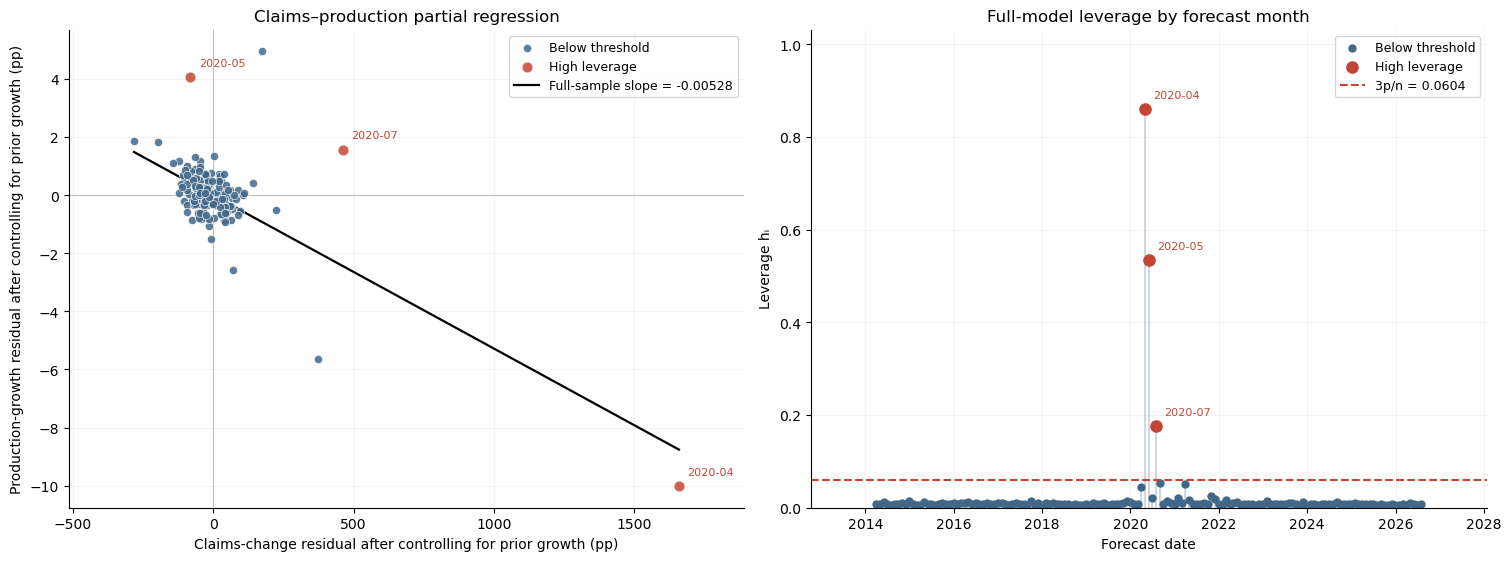

n=149, p=3, average leverage=0.0201, threshold=0.0604
Flagged: 3 observations (2.0% of the sample)


,target_month,claims_change,ip_growth_known,ip_growth_first,leverage,cooks_distance
forecast_date,,,,,,
2020-04-30,2020-04-01,2265.804935,-5.400892,-11.247702,0.859850,26.480491
2020-05-31,2020-05-01,1141.904762,-11.247702,1.389097,0.534657,12.623611
2020-07-31,2020-07-01,-72.848569,5.413863,3.028106,0.176137,1.615182


In [12]:
# 4. High-Leverage Diagnostics

# Reuse the exact regression sample and specification.
h1_plot_fit = h1_ols.fit()
h1_plot_influence = h1_plot_fit.get_influence()

design = np.asarray(h1_plot_fit.model.exog)
response = np.asarray(h1_plot_fit.model.endog)
dates = pd.DatetimeIndex(h1_plot_fit.model.data.row_labels)

n = len(response)
p = np.linalg.matrix_rank(design)  # Includes the intercept.
leverage_threshold = 3 * p / n

leverage = h1_plot_influence.hat_matrix_diag
high_leverage = leverage > leverage_threshold

assert np.isclose(leverage.sum(), p)

# Partial regression:
# Remove the intercept and production-growth control from both claims and y.
claims_position = h1_plot_fit.model.exog_names.index("claims_change")
claims_values = design[:, claims_position]
controls = np.delete(design, claims_position, axis=1)

claims_residual = sm.OLS(claims_values, controls).fit().resid
growth_residual = sm.OLS(response, controls).fit().resid
claims_beta = np.asarray(h1_plot_fit.params)[claims_position]

# Keep diagnostics for subsequent inspection.
h1_leverage_diagnostics = h1_panel.loc[dates].copy()
h1_leverage_diagnostics["leverage"] = leverage
h1_leverage_diagnostics["high_leverage"] = high_leverage
h1_leverage_diagnostics["cooks_distance"] = (
    h1_plot_influence.cooks_distance[0]
)

normal_color = "#416788"
flag_color = "#C44536"

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), constrained_layout=True)

# 1. Partial regression plot.
ax = axes[0]

for mask, color, label in [
    (~high_leverage, normal_color, "Below threshold"),
    (high_leverage, flag_color, "High leverage"),
]:
    ax.scatter(
        claims_residual[mask],
        growth_residual[mask],
        color=color,
        label=label,
        s=60 if mask is high_leverage else 35,
        alpha=0.85,
        edgecolor="white",
        linewidth=0.5,
        zorder=3,
    )

grid = np.linspace(claims_residual.min(), claims_residual.max(), 300)
ax.plot(
    grid,
    claims_beta * grid,
    color="black",
    linewidth=1.6,
    label=f"Full-sample slope = {claims_beta:.5f}",
)

ax.axhline(0, color="gray", linewidth=0.7, alpha=0.5)
ax.axvline(0, color="gray", linewidth=0.7, alpha=0.5)

ax.set(
    title="Claims–production partial regression",
    xlabel="Claims-change residual after controlling for prior growth (pp)",
    ylabel="Production-growth residual after controlling for prior growth (pp)",
)
ax.legend(fontsize=9)

# 2. Full-model leverage over time.
ax = axes[1]

ax.vlines(dates, 0, leverage, color=normal_color, alpha=0.25)
ax.scatter(
    dates[~high_leverage], leverage[~high_leverage],
    color=normal_color, s=25, label="Below threshold",
)
ax.scatter(
    dates[high_leverage], leverage[high_leverage],
    color=flag_color, s=65, label="High leverage", zorder=3,
)
ax.axhline(
    leverage_threshold,
    color=flag_color,
    linestyle="--",
    label=f"3p/n = {leverage_threshold:.4f}",
)

ax.set(
    title="Full-model leverage by forecast month",
    xlabel="Forecast date",
    ylabel="Leverage hᵢ",
    ylim=(0, min(1.05, max(leverage.max(), leverage_threshold) * 1.2)),
)
ax.legend(fontsize=9)

# Label every flagged observation in both plots.
for position in np.flatnonzero(high_leverage):
    label = dates[position].strftime("%Y-%m")

    axes[0].annotate(
        label,
        (claims_residual[position], growth_residual[position]),
        xytext=(6, 8),
        textcoords="offset points",
        fontsize=8,
        color=flag_color,
    )
    axes[1].annotate(
        label,
        (dates[position], leverage[position]),
        xytext=(6, 8),
        textcoords="offset points",
        fontsize=8,
        color=flag_color,
    )

for ax in axes:
    ax.grid(alpha=0.15)
    ax.spines[["top", "right"]].set_visible(False)
    ax.margins(x=0.12)

plt.show()

print(
    f"n={n}, p={p}, average leverage={p/n:.4f}, "
    f"threshold={leverage_threshold:.4f}"
)
print(
    f"Flagged: {high_leverage.sum()} observations "
    f"({high_leverage.mean():.1%} of the sample)"
)

display(
    h1_leverage_diagnostics.loc[
        high_leverage,
        [
            "target_month",
            "claims_change",
            "ip_growth_known",
            "ip_growth_first",
            "leverage",
            "cooks_distance",
        ],
    ].sort_values("leverage", ascending=False)
)

In [13]:
# 5. Without Leverage Regression

# Freeze exclusions from the ORIGINAL model; do not repeatedly trim.
h1_excluded_dates = h1_leverage_diagnostics.index[
    h1_leverage_diagnostics["high_leverage"]
]

h1_full_sample = h1_panel.loc[
    h1_plot_fit.model.data.row_labels
].copy().sort_index()

h1_trimmed_sample = h1_full_sample.drop(index=h1_excluded_dates)

print("Excluded:", ", ".join(h1_excluded_dates.strftime("%Y-%m")))
print(f"Observations: {len(h1_full_sample)} → {len(h1_trimmed_sample)}")


def claims_test_calendar_hac(sample, lags):
    """OLS coefficient test with Bartlett HAC using calendar-month distances."""
    sample = sample.sort_index()

    y_local = sample["ip_growth_first"].astype(float)
    X_local = sm.add_constant(
        sample[["ip_growth_known", "claims_change"]].astype(float),
        has_constant="add",
    )

    x = X_local.to_numpy()
    n_obs, n_params = x.shape
    months = pd.DatetimeIndex(sample.index).to_period("M")

    assert months.is_unique
    assert np.isfinite(x).all() and np.isfinite(y_local).all()
    assert np.linalg.matrix_rank(x) == n_params
    assert n_obs > n_params

    # The point estimates are ordinary OLS on retained observations.
    fit = sm.OLS(y_local, X_local).fit()

    # Bartlett weights depend on CALENDAR distance, not retained-row distance.
    # Excluded months are not filled with artificial observations.
    month_numbers = months.asi8
    distance = np.abs(
        month_numbers[:, None] - month_numbers[None, :]
    )
    weights = np.maximum(1.0 - distance / (lags + 1), 0.0)

    scores = x * np.asarray(fit.resid)[:, None]
    meat = scores.T @ weights @ scores
    bread = np.asarray(fit.normalized_cov_params)

    covariance = bread @ meat @ bread
    covariance *= n_obs / (n_obs - n_params)  # Same finite-sample correction.

    claims_pos = X_local.columns.get_loc("claims_change")
    beta = float(fit.params["claims_change"])
    se = float(np.sqrt(covariance[claims_pos, claims_pos]))
    z = beta / se
    critical = norm.ppf(0.975)

    return {
        "n_months": n_obs,
        "beta_claims": beta,
        "HAC_SE": se,
        "z_stat": z,
        "Wald_chi2_1": z**2,
        "p_two_sided": 2 * norm.sf(abs(z)),
        "CI_95_low": beta - critical * se,
        "CI_95_high": beta + critical * se,
        "IP_growth_pp_per_10pp_claims_change": 10 * beta,
    }


# Original data and fitted models remain unchanged.
h1_exclusion_results = pd.DataFrame([
    {
        "sample": sample_name,
        "HAC_lags": lags,
        **claims_test_calendar_hac(sample, lags),
    }
    for sample_name, sample in [
        ("Full sample", h1_full_sample),
        ("Without flagged months", h1_trimmed_sample),
    ]
    for lags in [3, 6, 12]
]).set_index(["sample", "HAC_lags"])

# Verify the calendar calculation reproduces the original complete-sample HAC.
for lags in [3, 6, 12]:
    np.testing.assert_allclose(
        h1_exclusion_results.loc[
            ("Full sample", lags), ["beta_claims", "HAC_SE"]
        ].to_numpy(dtype=float),
        [
            h1_fits[lags].params["claims_change"],
            h1_fits[lags].bse["claims_change"],
        ],
        rtol=1e-8,
        atol=1e-10,
    )

h1_exclusion_primary = h1_exclusion_results.xs(6, level="HAC_lags")

print("\nPrimary comparison: HAC(6), two-sided asymptotic normal test")
display(h1_exclusion_primary.style.format({
    "n_months": "{:.0f}",
    "beta_claims": "{:.6f}",
    "HAC_SE": "{:.6f}",
    "z_stat": "{:.3f}",
    "Wald_chi2_1": "{:.3f}",
    "p_two_sided": "{:.3e}",
    "CI_95_low": "{:.6f}",
    "CI_95_high": "{:.6f}",
    "IP_growth_pp_per_10pp_claims_change": "{:.4f}",
}))

print("\nBandwidth sensitivity")
display(
    h1_exclusion_results[
        ["beta_claims", "HAC_SE", "p_two_sided"]
    ].style.format({
        "beta_claims": "{:.6f}",
        "HAC_SE": "{:.6f}",
        "p_two_sided": "{:.3e}",
    })
)

before = h1_exclusion_primary.loc["Full sample"]
after = h1_exclusion_primary.loc["Without flagged months"]

print(f"\nClaims coefficient: {before['beta_claims']:.6f}"
      f" → {after['beta_claims']:.6f}")
print(f"HAC SE multiplier: {after['HAC_SE'] / before['HAC_SE']:.2f}×")
print(f"Two-sided p-value: {before['p_two_sided']:.3e}"
      f" → {after['p_two_sided']:.3e}")

if not np.isclose(before["beta_claims"], 0):
    magnitude_change = (
        abs(after["beta_claims"]) / abs(before["beta_claims"]) - 1
    ) * 100
    print(f"Change in coefficient magnitude: {magnitude_change:+.1f}%")

if after["p_two_sided"] >= 0.05:
    print("After exclusion: insufficient evidence to reject H0 at nominal 5%.")
elif after["beta_claims"] < 0:
    print("After exclusion: the negative association remains nominally significant.")
else:
    print("After exclusion: a positive association is nominally significant,"
          " contrary to the hypothesized direction.")

Excluded: 2020-04, 2020-05, 2020-07
Observations: 149 → 146

Primary comparison: HAC(6), two-sided asymptotic normal test


,n_months,beta_claims,HAC_SE,z_stat,Wald_chi2_1,p_two_sided,CI_95_low,CI_95_high,IP_growth_pp_per_10pp_claims_change
sample,,,,,,,,,
Full sample,149,-0.005280,0.000781,-6.763,45.744,1.347e-11,-0.006810,-0.003750,-0.0528
Without flagged months,146,-0.012008,0.002938,-4.087,16.700,4.378e-05,-0.017767,-0.006249,-0.1201



Bandwidth sensitivity



Claims coefficient: -0.005280 → -0.012008
HAC SE multiplier: 3.76×
Two-sided p-value: 1.347e-11 → 4.378e-05
Change in coefficient magnitude: +127.4%
After exclusion: the negative association remains nominally significant.


In [14]:
from scipy.stats import chi2

# Preserve the original panel and fitted models.
h1_audit = h1_panel.copy().sort_index()

H1_Y = "ip_growth_first"
H1_X = ["ip_growth_known", "claims_change"]
H1_L = 6

assert h1_audit.index.is_unique
assert (h1_audit["target_release"] > h1_audit.index).all()
assert (h1_audit["ip_vintage_used"] <= h1_audit.index).all()


def fit_calendar_hac(data, ycol, xcols, L=6):
    d = data[[ycol] + list(xcols)].dropna().astype(float).sort_index()
    months = pd.DatetimeIndex(d.index).to_period("M")

    if not months.is_unique:
        raise ValueError("More than one observation per calendar month.")

    X = sm.add_constant(d[list(xcols)], has_constant="add")
    x = X.to_numpy()
    n, p = x.shape

    if n <= p or np.linalg.matrix_rank(x) < p:
        raise ValueError("Insufficient observations or rank-deficient design.")
    if not np.isfinite(d.to_numpy()).all():
        raise ValueError("Nonfinite regression input.")

    f = sm.OLS(d[ycol], X).fit()

    scores = x * np.asarray(f.resid)[:, None]
    distance = np.abs(months.asi8[:, None] - months.asi8[None, :])
    weights = np.maximum(1 - distance / (L + 1), 0)

    bread = np.asarray(f.normalized_cov_params)
    v = (n / (n - p)) * bread @ (scores.T @ weights @ scores) @ bread
    v = (v + v.T) / 2

    V = pd.DataFrame(v, index=X.columns, columns=X.columns)
    se = pd.Series(np.sqrt(np.diag(v)), index=X.columns)
    z = f.params / se

    tab = pd.DataFrame({
        "beta": f.params,
        "SE": se,
        "z": z,
        "p_two_sided": 2 * norm.sf(np.abs(z)),
        "CI_low": f.params - norm.ppf(.975) * se,
        "CI_high": f.params + norm.ppf(.975) * se,
    })
    return f, V, tab


def wald_zero(f, V, terms):
    """H0: all named coefficients equal zero."""
    b = f.params.loc[terms].to_numpy()
    v = V.loc[terms, terms].to_numpy()

    if np.linalg.matrix_rank(v) < len(terms):
        raise ValueError("Singular covariance for the requested restriction.")

    W = float(b @ np.linalg.solve(v, b))
    return {
        "Wald": W,
        "df": len(terms),
        "p": chi2.sf(W, len(terms)),
    }


def show_results(table):
    p_formats = {
        c: "{:.3e}" for c in table.columns
        if str(c).startswith("p")
    }
    display(table.style.format(precision=5).format(p_formats))


# Confirm that the helper reproduces the existing full-sample calculation.
_, _, h1_check = fit_calendar_hac(h1_audit, H1_Y, H1_X, H1_L)

np.testing.assert_allclose(
    h1_check.loc["claims_change", ["beta", "SE"]].to_numpy(dtype=float),
    [
        h1_fits[6].params["claims_change"],
        h1_fits[6].bse["claims_change"],
    ],
    rtol=1e-8,
    atol=1e-10,
)

In [15]:
# 1A. Fixed sample comparisons

h1_flagged_dates = h1_leverage_diagnostics.index[
    h1_leverage_diagnostics["high_leverage"]
]

h1_samples = {
    "Full": h1_audit,
    "Without original flags": h1_audit.drop(index=h1_flagged_dates),
    "Outside 2020–2021": h1_audit.loc[
        ~h1_audit.index.year.isin([2020, 2021])
    ],
    "Pre-2020": h1_audit.loc[h1_audit.index.year < 2020],
    "2022 onward": h1_audit.loc[h1_audit.index.year >= 2022],
}

h1_episode_fits = {}
episode_rows = []

for name, sample in h1_samples.items():
    f, V, tab = fit_calendar_hac(sample, H1_Y, H1_X, H1_L)
    h1_episode_fits[name] = (f, V, tab)

    episode_rows.append({
        "sample": name,
        "n": int(f.nobs),
        **tab.loc["claims_change"].to_dict(),
        "effect_per_10pp": 10 * f.params["claims_change"],
    })

h1_episode_results = pd.DataFrame(episode_rows).set_index("sample")
show_results(h1_episode_results)


# 1B. Formal pre/post claims-slope comparison

h1_interaction_data = h1_samples["Outside 2020–2021"].copy()

h1_interaction_data["post"] = (
    h1_interaction_data.index.year >= 2022
).astype(float)

h1_interaction_data["post_ip"] = (
    h1_interaction_data["post"] *
    h1_interaction_data["ip_growth_known"]
)
h1_interaction_data["post_claims"] = (
    h1_interaction_data["post"] *
    h1_interaction_data["claims_change"]
)

f, V, tab = fit_calendar_hac(
    h1_interaction_data,
    H1_Y,
    H1_X + ["post", "post_ip", "post_claims"],
    H1_L,
)

print("Post-minus-pre difference in the claims coefficient:")
show_results(tab.loc[["post_claims"]])

print("H0: pre/post claims slopes are equal")
show_results(pd.DataFrame([
    wald_zero(f, V, ["post_claims"])
]))


# 1C. Leave-one-calendar-year-out sensitivity

year_rows = []

for year in sorted(h1_audit.index.year.unique()):
    sample = h1_audit.loc[h1_audit.index.year != year]
    f, V, tab = fit_calendar_hac(sample, H1_Y, H1_X, H1_L)

    year_rows.append({
        "excluded_year": year,
        "n_removed": int((h1_audit.index.year == year).sum()),
        "beta": tab.loc["claims_change", "beta"],
        "CI_low": tab.loc["claims_change", "CI_low"],
        "CI_high": tab.loc["claims_change", "CI_high"],
    })

h1_leave_year_out = pd.DataFrame(year_rows).set_index("excluded_year")
show_results(h1_leave_year_out)


# 1D. Recompute influence AFTER the original three exclusions.
# These flags are diagnostic only; no further observations are deleted.

f = h1_episode_fits["Without original flags"][0]
influence = f.get_influence()
p = f.model.exog.shape[1]
claims_pos = f.model.exog_names.index("claims_change")

h1_refit_influence = pd.DataFrame({
    "leverage": influence.hat_matrix_diag,
    "Cook_D": influence.cooks_distance[0],
    "DFBETA_claims": influence.dfbetas[:, claims_pos],
}, index=f.model.data.row_labels)

h1_refit_influence["high_leverage"] = (
    h1_refit_influence["leverage"] > 3 * p / f.nobs
)

print(f"Refitted leverage threshold: {3 * p / f.nobs:.5f}")
show_results(h1_refit_influence.nlargest(8, "Cook_D"))

,n,beta,SE,z,p_two_sided,CI_low,CI_high,effect_per_10pp
sample,,,,,,,,
Full,149,-0.005280,0.000781,-6.763464,1.347e-11,-0.006810,-0.003750,-0.052798
Without original flags,146,-0.012008,0.002938,-4.086544,4.378e-05,-0.017767,-0.006249,-0.120079
Outside 2020–2021,125,-0.006206,0.004898,-1.267088,2.051e-01,-0.015806,0.003394,-0.062060
Pre-2020,70,-0.011621,0.011358,-1.023170,3.062e-01,-0.033882,0.010640,-0.116211
2022 onward,55,-0.005217,0.005415,-0.963506,3.353e-01,-0.015831,0.005396,-0.052174


Post-minus-pre difference in the claims coefficient:


,beta,SE,z,p_two_sided,CI_low,CI_high
post_claims,0.006404,0.012602,0.508136,6.114e-01,-0.018297,0.031104


H0: pre/post claims slopes are equal


,Wald,df,p
0,0.258202,1,6.114e-01


,n_removed,beta,CI_low,CI_high
excluded_year,,,,
2014,10,-0.005250,-0.006817,-0.003683
2015,12,-0.005381,-0.006894,-0.003869
2016,12,-0.005287,-0.006847,-0.003726
2017,12,-0.005295,-0.006844,-0.003747
2018,12,-0.005274,-0.006820,-0.003728
2019,12,-0.005309,-0.006855,-0.003762
2020,12,-0.011074,-0.018222,-0.003926
2021,12,-0.005242,-0.006918,-0.003565
2022,12,-0.005323,-0.006867,-0.003779


Refitted leverage threshold: 0.06164


,leverage,Cook_D,DFBETA_claims,high_leverage
forecast_date,,,,
2020-03-31 00:00:00,0.818760,26.164786,-9.368802,True
2020-06-30 00:00:00,0.057726,1.342833,1.864562,False
2021-03-31 00:00:00,0.113417,0.074036,-0.042389,True
2021-02-28 00:00:00,0.016199,0.048620,-0.077231,False
2021-10-31 00:00:00,0.050517,0.034812,-0.091127,False
2021-01-31 00:00:00,0.039711,0.022780,0.042714,False
2020-09-30 00:00:00,0.020190,0.021502,0.205200,False
2020-08-31 00:00:00,0.163734,0.012627,0.067030,True


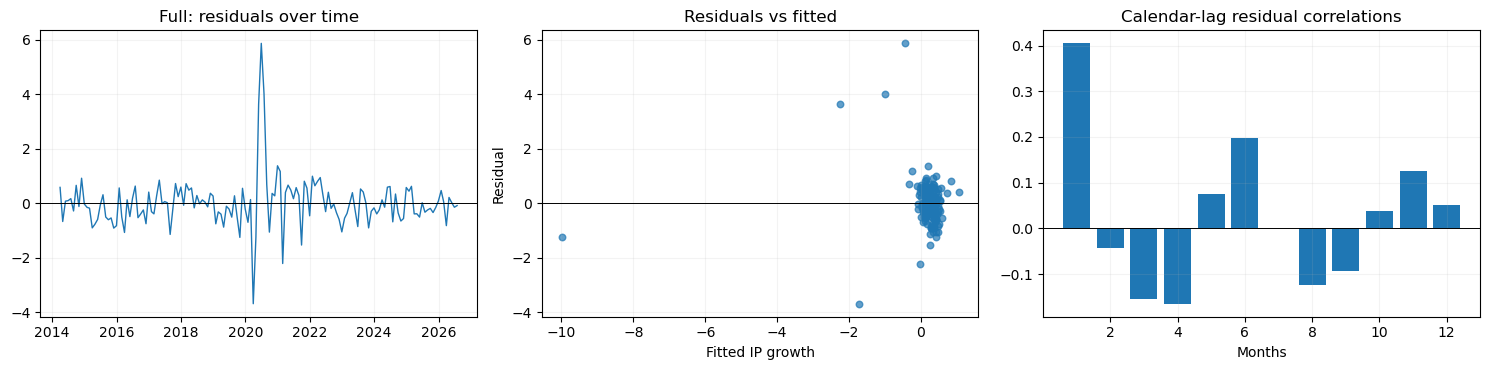

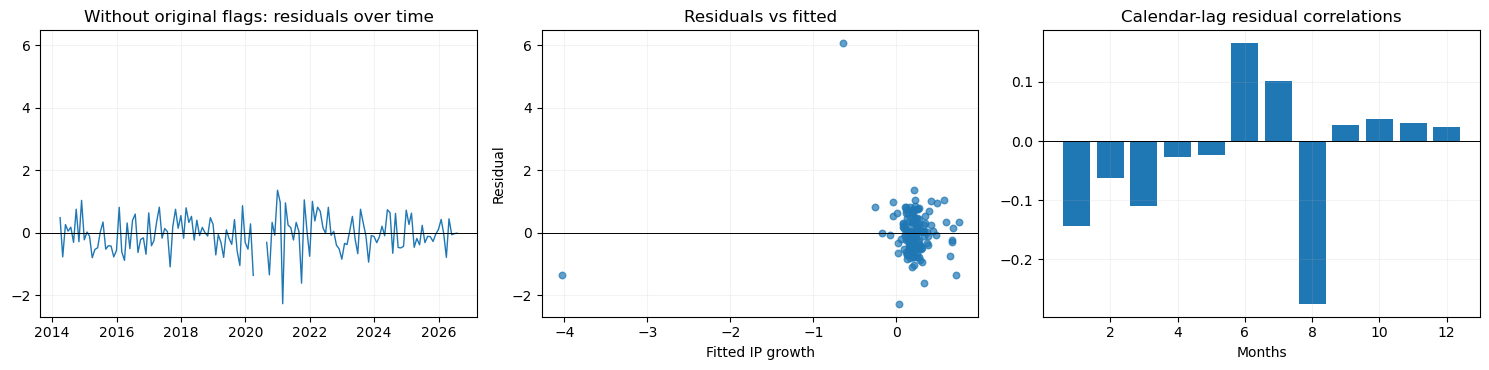

,sample,test,n_auxiliary,Wald,df,p
0,Full,Residual lags 1–6,143,145.277260,6,7.704e-29
1,Full,RESET powers 2–3,149,4.258545,2,1.189e-01
2,Without original flags,Residual lags 1–6,133,9.706780,6,1.376e-01
3,Without original flags,RESET powers 2–3,146,12.896244,2,1.583e-03


In [16]:
# 2A. Calendar-aware residual diagnostics

diagnostic_rows = []

for name in ["Full", "Without original flags"]:
    sample = h1_samples[name]
    f, V, tab = h1_episode_fits[name]

    # Residuals on a complete monthly calendar; excluded months remain missing.
    u = f.resid.copy()
    u.index = u.index.to_period("M")
    u = u.reindex(pd.period_range(u.index.min(), u.index.max(), freq="M"))

    lagged = pd.DataFrame({
        f"u_lag{k}": u.shift(k) for k in range(1, 7)
    })
    lagged.index = lagged.index.to_timestamp("M")

    auxiliary = pd.concat(
        [sample[H1_X], f.resid.rename("u"), lagged],
        axis=1,
    ).dropna()

    af, av, _ = fit_calendar_hac(
        auxiliary,
        "u",
        H1_X + list(lagged.columns),
        H1_L,
    )

    diagnostic_rows.append({
        "sample": name,
        "test": "Residual lags 1–6",
        "n_auxiliary": int(af.nobs),
        **wald_zero(af, av, list(lagged.columns)),
    })

    # RESET-style powers of standardized fitted values.
    standardized_fit = (
        (f.fittedvalues - f.fittedvalues.mean()) /
        f.fittedvalues.std()
    )

    reset_data = sample.copy()
    reset_data["fitted_sq"] = standardized_fit**2
    reset_data["fitted_cube"] = standardized_fit**3

    rf, rv, _ = fit_calendar_hac(
        reset_data,
        H1_Y,
        H1_X + ["fitted_sq", "fitted_cube"],
        H1_L,
    )

    diagnostic_rows.append({
        "sample": name,
        "test": "RESET powers 2–3",
        "n_auxiliary": int(rf.nobs),
        **wald_zero(rf, rv, ["fitted_sq", "fitted_cube"]),
    })

    # Descriptive plots; no normality assumption is imposed.
    fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))

    axes[0].plot(u.index.to_timestamp("M"), u, linewidth=1)
    axes[0].set_title(f"{name}: residuals over time")

    axes[1].scatter(f.fittedvalues, f.resid, s=22, alpha=.7)
    axes[1].set(
        title="Residuals vs fitted",
        xlabel="Fitted IP growth",
        ylabel="Residual",
    )

    lags = np.arange(1, 13)
    correlations = [u.autocorr(lag=int(k)) for k in lags]
    axes[2].bar(lags, correlations)
    axes[2].set(
        title="Calendar-lag residual correlations",
        xlabel="Months",
    )

    for ax in axes:
        ax.axhline(0, color="black", linewidth=.7)
        ax.grid(alpha=.15)

    plt.tight_layout()
    plt.show()

h1_diagnostic_results = pd.DataFrame(diagnostic_rows)
show_results(h1_diagnostic_results)

In [17]:
# 2B. Point-in-time additional growth controls and log claims

h1_spec_data = h1_audit.copy()
h1_ip_grid = indpro_vintages.sort_index().sort_index(axis=1).asfreq("MS")

if (h1_spec_data["claims_change"] <= -100).any():
    raise ValueError("Log claims transformation requires claims_change > -100.")

h1_spec_data["claims_log"] = (
    100 * np.log1p(h1_spec_data["claims_change"] / 100)
)

# Use the SAME historical vintage available at each forecast origin.
for origin, row in h1_spec_data.iterrows():
    published_growth = (
        100 *
        h1_ip_grid[row["ip_vintage_used"]].pct_change(fill_method=None)
    )

    for lag in [2, 3]:
        month = row["ip_month_used"] - pd.DateOffset(months=lag - 1)
        h1_spec_data.loc[origin, f"ip_known_{lag}"] = (
            published_growth.get(month, np.nan)
        )

h1_spec_common = h1_spec_data.dropna(subset=[
    H1_Y, "ip_growth_known", "ip_known_2", "ip_known_3",
    "claims_change", "claims_log",
])

specifications = {
    "Original": ("claims_change", ["ip_growth_known"]),
    "Log claims": ("claims_log", ["ip_growth_known"]),
    "Three IP controls": (
        "claims_change",
        ["ip_growth_known", "ip_known_2", "ip_known_3"],
    ),
    "Log + three IP controls": (
        "claims_log",
        ["ip_growth_known", "ip_known_2", "ip_known_3"],
    ),
}

spec_rows = []

for sample_name in ["Full", "Outside 2020–2021"]:
    sample = h1_spec_common.loc[
        h1_spec_common.index.intersection(h1_samples[sample_name].index)
    ]

    for spec_name, (claims_term, controls) in specifications.items():
        f, V, tab = fit_calendar_hac(
            sample, H1_Y, controls + [claims_term], H1_L
        )

        contrast = (
            10 if claims_term == "claims_change"
            else 100 * np.log1p(.10)
        )
        result = tab.loc[claims_term]

        extra_p = np.nan
        if "ip_known_2" in controls:
            extra_p = wald_zero(
                f, V, ["ip_known_2", "ip_known_3"]
            )["p"]

        spec_rows.append({
            "sample": sample_name,
            "specification": spec_name,
            "n": int(f.nobs),
            "beta": result["beta"],
            "p_two_sided": result["p_two_sided"],
            "effect_0_to_10pct": contrast * result["beta"],
            "effect_CI_low": contrast * result["CI_low"],
            "effect_CI_high": contrast * result["CI_high"],
            "p_extra_IP_controls": extra_p,
        })

h1_spec_results = pd.DataFrame(spec_rows)
show_results(h1_spec_results)

,sample,specification,n,beta,p_two_sided,effect_0_to_10pct,effect_CI_low,effect_CI_high,p_extra_IP_controls
0,Full,Original,147,-0.005277,1.578e-11,-0.052767,-0.068110,-0.037423,nan
1,Full,Log claims,147,-0.026474,7.969e-04,-0.252328,-0.399784,-0.104871,nan
2,Full,Three IP controls,147,-0.005826,8.608e-22,-0.058256,-0.070159,-0.046353,3.768e-05
3,Full,Log + three IP controls,147,-0.033635,6.611e-06,-0.320575,-0.460020,-0.181131,9.297e-05
4,Outside 2020–2021,Original,123,-0.006012,2.269e-01,-0.060124,-0.157648,0.037400,nan
5,Outside 2020–2021,Log claims,123,-0.007191,1.852e-01,-0.068540,-0.169942,0.032862,nan
6,Outside 2020–2021,Three IP controls,123,-0.006349,1.742e-01,-0.063489,-0.155062,0.028084,1.653e-01
7,Outside 2020–2021,Log + three IP controls,123,-0.007307,1.419e-01,-0.069644,-0.162572,0.023284,1.583e-01


In [18]:
# 2C. Moving-block pairs bootstrap within contiguous segments

def block_beta_ci(
    data, ycol, xcols, term,
    block=6, B=3999, seed=917,
):
    d = data[[ycol] + list(xcols)].dropna().sort_index()
    X = sm.add_constant(d[list(xcols)], has_constant="add").to_numpy()
    y = d[ycol].to_numpy()
    pos = 1 + list(xcols).index(term)

    month = d.index.to_period("M").asi8
    segments = np.split(
        np.arange(len(d)),
        np.flatnonzero(np.diff(month) != 1) + 1,
    )

    if min(map(len, segments)) < block:
        raise ValueError("A contiguous segment is shorter than the block length.")

    rng = np.random.default_rng(seed)
    draws = []

    for _ in range(B):
        sampled = []

        for segment in segments:
            n = len(segment)
            starts = rng.integers(
                0, n - block + 1,
                size=int(np.ceil(n / block)),
            )
            locations = (
                starts[:, None] + np.arange(block)
            ).ravel()[:n]

            sampled.append(segment[locations])

        idx = np.concatenate(sampled)
        beta, _, rank, _ = np.linalg.lstsq(X[idx], y[idx], rcond=None)

        if rank == X.shape[1]:
            draws.append(beta[pos])

    if len(draws) < .99 * B:
        raise ValueError("Too many rank-deficient bootstrap samples.")

    low, high = np.quantile(draws, [.025, .975])

    return {
        "block_months": block,
        "valid_draws": len(draws),
        "bootstrap_SE": np.std(draws, ddof=1),
        "CI_low": low,
        "CI_high": high,
    }


h1_bootstrap_results = pd.DataFrame([
    block_beta_ci(
        h1_samples["Outside 2020–2021"],
        H1_Y, H1_X, "claims_change",
        block=block,
    )
    for block in [6, 12]
])

print("Point estimate outside 2020–2021:")
print(
    h1_episode_results.loc["Outside 2020–2021", "beta"]
)

show_results(h1_bootstrap_results)

Point estimate outside 2020–2021:
-0.006205994008076526


,block_months,valid_draws,bootstrap_SE,CI_low,CI_high
0,6,3999,0.004644,-0.011992,0.007034
1,12,3999,0.005163,-0.009669,0.011176


In [19]:
# 2D. Compare first-release and twelve-month-maturity targets

h1_maturity_data = h1_audit.copy()
h1_maturity_data["ip_growth_12m"] = np.nan

for origin, row in h1_maturity_data.iterrows():
    cutoff = row["target_release"] + pd.DateOffset(months=12)
    available = h1_ip_grid.columns[h1_ip_grid.columns <= cutoff]

    # Do not substitute a shorter maturity for recent observations.
    if cutoff > h1_ip_grid.columns.max() or len(available) == 0:
        continue

    vintage = available[-1]
    growth = 100 * h1_ip_grid[vintage].pct_change(fill_method=None)

    h1_maturity_data.loc[origin, "ip_growth_12m"] = growth.get(
        row["target_month"], np.nan
    )

h1_maturity_common = h1_maturity_data.dropna(
    subset=[H1_Y, "ip_growth_12m"] + H1_X
)

maturity_rows = []

for target in [H1_Y, "ip_growth_12m"]:
    f, V, tab = fit_calendar_hac(
        h1_maturity_common, target, H1_X, H1_L
    )
    maturity_rows.append({
        "target": target,
        "n": int(f.nobs),
        **tab.loc["claims_change"].to_dict(),
    })

h1_maturity_results = pd.DataFrame(maturity_rows).set_index("target")
show_results(h1_maturity_results)

revision = (
    h1_maturity_common["ip_growth_12m"] -
    h1_maturity_common[H1_Y]
)

print(f"Mean absolute growth revision: {revision.abs().mean():.4f} pp")

,n,beta,SE,z,p_two_sided,CI_low,CI_high
target,,,,,,,
ip_growth_first,137,-0.005291,0.000784,-6.750928,1.469e-11,-0.006827,-0.003755
ip_growth_12m,137,-0.005641,0.000946,-5.965805,2.434e-09,-0.007494,-0.003788


Mean absolute growth revision: 0.3023 pp


79 forecasts: 2020-01-31 to 2026-07-31
Initial training sample: 70


,actual,n_train,latest_training_release,baseline,claims,e0,e1,loss_gain,cw_adjusted
forecast_date,,,,,,,,,
2020-01-31,-0.308652,70,2020-01-17,0.232386,0.219846,-0.541038,-0.528499,0.013412,0.013569
2020-02-29,0.554315,71,2020-02-14,0.221212,0.260494,0.333103,0.293822,0.024627,0.026170
2020-03-31,-5.400892,72,2020-03-17,0.075917,-4.343167,-5.476809,-1.057725,28.876654,48.404958
2020-04-30,-11.247702,73,2020-04-15,1.700038,-34.126016,-12.947740,22.878315,-355.773314,927.732847
2020-05-31,1.389097,74,2020-05-15,-12.970153,-2.461370,14.359250,3.850467,191.361976,301.796500


,n,MAE_baseline,MAE_claims,RMSE_baseline,RMSE_claims,R2_OOS,mean_squared_loss_gain
All forecasts,79.000000,0.958815,0.968325,2.435194,2.852882,-0.372463,-2.208770
2020–2021,24.000000,2.291028,2.245827,4.357183,5.122446,-0.382112,-7.254407
2022 onward,55.000000,0.377485,0.410870,0.483212,0.490440,-0.030141,-0.007038


,primary,mean_CW_adjustment,HAC_SE_of_mean,CW_statistic,p_CW_one_sided
HAC_lags,,,,,
3,0.000e+00,16.088169,14.765283,1.089594,1.379e-01
6,1.000e+00,16.088169,14.921384,1.078196,1.405e-01
12,0.000e+00,16.088169,14.992386,1.073089,1.416e-01


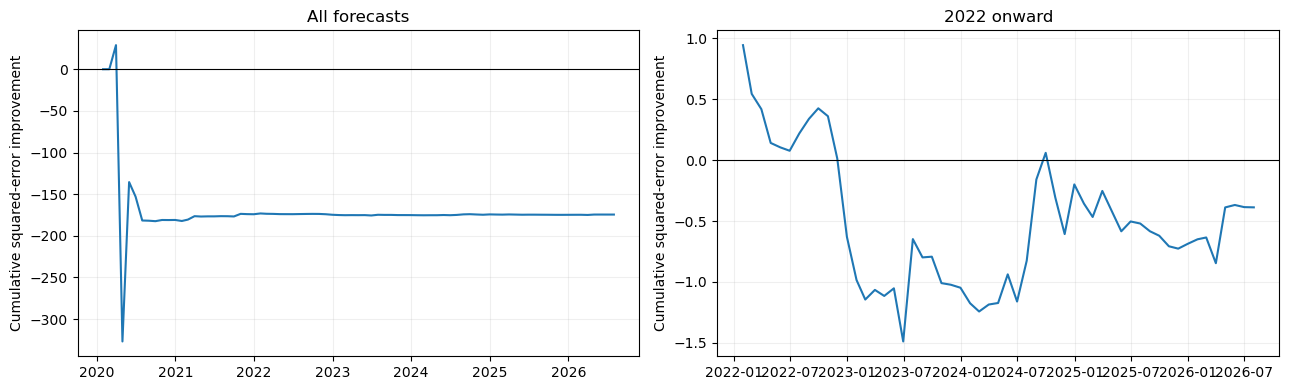

In [20]:
# 3A. Release-aware expanding-window forecasts

def walk_forward(data, start="2020-01-01", min_train=60):
    d = data.sort_index()
    rows = []

    specs = {
        "baseline": ["ip_growth_known"],
        "claims": ["ip_growth_known", "claims_change"],
    }

    for origin, row in d.loc[start:].iterrows():
        train = d.loc[
            (d.index < origin) &
            (d["target_release"] <= origin)
        ]

        train = train.dropna(subset=[
            "ip_growth_first", "ip_growth_known", "claims_change",
        ])

        if len(train) < min_train:
            continue

        assert train["target_release"].max() <= origin
        assert row["target_release"] > origin

        out = {
            "forecast_date": origin,
            "actual": row["ip_growth_first"],
            "n_train": len(train),
            "latest_training_release": train["target_release"].max(),
        }

        for name, cols in specs.items():
            X = sm.add_constant(train[cols], has_constant="add")

            if np.linalg.matrix_rank(X.to_numpy()) != X.shape[1]:
                raise ValueError(
                    f"Rank-deficient training design at {origin}."
                )

            f = sm.OLS(train["ip_growth_first"], X).fit()
            new_x = np.r_[1., row[cols].to_numpy(dtype=float)]

            out[name] = float(new_x @ f.params.to_numpy())

        rows.append(out)

    if not rows:
        raise ValueError("No forecast origins have enough released targets.")

    out = pd.DataFrame(rows).set_index("forecast_date")

    out["e0"] = out["actual"] - out["baseline"]
    out["e1"] = out["actual"] - out["claims"]
    out["loss_gain"] = out["e0"]**2 - out["e1"]**2
    out["cw_adjusted"] = (
        out["loss_gain"] +
        (out["baseline"] - out["claims"])**2
    )

    return out


# Use the original full panel—not an ex-post trimmed training sample.
h1_oos = walk_forward(h1_audit)

print(
    f"{len(h1_oos)} forecasts: "
    f"{h1_oos.index.min().date()} to {h1_oos.index.max().date()}"
)
print(f"Initial training sample: {h1_oos['n_train'].iloc[0]}")

display(h1_oos.head())


# 3B. Realized forecast performance

def forecast_metrics(d):
    mse0 = np.mean(d["e0"]**2)
    mse1 = np.mean(d["e1"]**2)

    return {
        "n": len(d),
        "MAE_baseline": d["e0"].abs().mean(),
        "MAE_claims": d["e1"].abs().mean(),
        "RMSE_baseline": np.sqrt(mse0),
        "RMSE_claims": np.sqrt(mse1),
        "R2_OOS": 1 - mse1 / mse0,
        "mean_squared_loss_gain": mse0 - mse1,
    }


evaluation_periods = {
    "All forecasts": h1_oos,
    "2020–2021": h1_oos.loc[h1_oos.index.year.isin([2020, 2021])],
    "2022 onward": h1_oos.loc[h1_oos.index.year >= 2022],
}

h1_forecast_metrics = pd.DataFrame({
    name: forecast_metrics(d)
    for name, d in evaluation_periods.items()
    if len(d) > 0
}).T

show_results(h1_forecast_metrics)


# 3C. Clark–West: HAC(6) primary; HAC(3)/(12) sensitivity

cw_rows = []

for L in [3, 6, 12]:
    _, _, tab = fit_calendar_hac(
        h1_oos, "cw_adjusted", [], L=L
    )

    mean = tab.loc["const", "beta"]
    se = tab.loc["const", "SE"]
    statistic = mean / se

    cw_rows.append({
        "HAC_lags": L,
        "primary": L == 6,
        "mean_CW_adjustment": mean,
        "HAC_SE_of_mean": se,
        "CW_statistic": statistic,
        "p_CW_one_sided": norm.sf(statistic),
    })

h1_cw_results = pd.DataFrame(cw_rows).set_index("HAC_lags")
show_results(h1_cw_results)


# 3D. When did the gains occur?
# Upward movement means lower squared error for the claims model.

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, name in zip(axes, ["All forecasts", "2022 onward"]):
    d = evaluation_periods[name]
    ax.plot(d.index, d["loss_gain"].cumsum())
    ax.axhline(0, color="black", linewidth=.8)
    ax.set(
        title=name,
        ylabel="Cumulative squared-error improvement",
    )
    ax.grid(alpha=.2)

plt.tight_layout()
plt.show()

### 3.2 Hypothesis 2: Has Cleveland inflation nowcast improved?

In [21]:
# 1. Retrieve historical CPI and release Dates

# Freeze the information cutoff for this research run.
H2_AS_OF = pd.Timestamp("2026-09-10")

# These months lack official monthly CPI inflation readings.
# Do not substitute Cleveland's model estimates as realized outcomes.
H2_UNOFFICIAL_MONTHS = pd.DatetimeIndex(
    ["2025-10-01", "2025-11-01"]
)


def h2_fred_rows(endpoint, result_key, **parameters):
    key = os.getenv("FRED_API_KEY")

    if not key:
        raise RuntimeError(
            "Run your .env configuration cell first: "
            "FRED_API_KEY is missing."
        )

    params = {
        "api_key": key,
        "file_type": "json",
        "limit": 10000,
        "offset": 0,
        **parameters,
    }

    records = []

    with requests.Session() as session:
        while True:
            try:
                response = session.get(
                    f"https://api.stlouisfed.org/fred/{endpoint}",
                    params=params,
                    timeout=60,
                )
                response.raise_for_status()
                payload = response.json()

            except (requests.RequestException, ValueError):
                # Avoid exposing a request URL containing the API key.
                raise RuntimeError(
                    f"FRED {endpoint} failed; check key/connectivity."
                ) from None

            if result_key not in payload or "count" not in payload:
                raise RuntimeError(
                    f"Unexpected FRED response for {endpoint}."
                )

            batch = payload[result_key]
            records.extend(batch)
            params["offset"] += len(batch)

            if params["offset"] >= int(payload["count"]):
                break

            if not batch:
                raise RuntimeError(
                    f"Incomplete FRED pagination for {endpoint}."
                )

    if not records:
        raise RuntimeError(f"No records returned for {endpoint}.")

    return pd.DataFrame(records)


h2_start_month = pd.Timestamp(
    inflation_nowcast_long.index
    .get_level_values("target_month")
    .min()
)

# Extra history provides the baseline's numerator and denominator.
h2_history_start = (
    h2_start_month - pd.DateOffset(years=1)
).strftime("%Y-%m-%d")

h2_end = H2_AS_OF.strftime("%Y-%m-%d")

h2_cpi_history = h2_fred_rows(
    "series/observations",
    "observations",
    series_id="CPIAUCSL",  # Headline CPI, monthly, seasonally adjusted.
    observation_start=h2_history_start,
    observation_end=h2_end,
    realtime_start=h2_history_start,
    realtime_end=h2_end,
    units="lin",
    output_type=1,         # Observation values by validity interval.
    sort_order="asc",
)

h2_cpi_history["date"] = pd.to_datetime(
    h2_cpi_history["date"]
)

h2_cpi_history["value"] = pd.to_numeric(
    h2_cpi_history["value"].replace(".", np.nan),
    errors="raise",
)

# Keep validity endpoints as ISO strings: some may contain year 9999.
# Keep missing values; they must not be forward-filled.
h2_cpi_history = h2_cpi_history.sort_values(
    ["date", "realtime_start"]
)

if h2_cpi_history.duplicated(["date", "realtime_start"]).any():
    raise ValueError("Duplicate CPI observation/vintage records.")

if not h2_cpi_history["date"].dt.is_month_start.all():
    raise ValueError("Unexpected CPI observation frequency.")

h2_values = h2_cpi_history["value"].dropna()

if (
    h2_values.empty
    or not np.isfinite(h2_values).all()
    or h2_values.le(0).any()
):
    raise ValueError("Invalid CPI index levels.")

h2_cpi_release_dates = h2_fred_rows(
    "release/dates",
    "release_dates",
    release_id=10,  # Consumer Price Index.
    realtime_start=h2_history_start,
    realtime_end=h2_end,
    include_release_dates_with_no_data="false",
    sort_order="asc",
)

h2_cpi_release_dates["date"] = pd.to_datetime(
    h2_cpi_release_dates["date"]
)

print(f"CPI vintage records: {len(h2_cpi_history):,}")
print(f"CPI release-calendar dates: {len(h2_cpi_release_dates):,}")

CPI vintage records: 861
CPI release-calendar dates: 179


In [22]:
# 2. Construct monthly evaluation calendar

def h2_snapshot(history, as_of):
    """CPI index history available at the end of a specified date."""
    day = pd.Timestamp(as_of).strftime("%Y-%m-%d")

    active = (
        history.loc[
            history["realtime_start"].le(day)
            & history["realtime_end"].ge(day)
            & history["date"].le(pd.Timestamp(as_of))
        ]
        .set_index("date")
        .sort_index()
    )

    if active.index.has_duplicates:
        raise ValueError(f"Overlapping CPI vintages on {day}.")

    return active


def h2_mom(snapshot):
    """Nonannualized MoM percent changes within ONE vintage."""
    if snapshot.empty:
        return pd.Series(
            dtype=float,
            index=pd.DatetimeIndex([]),
        )

    # Preserve missing calendar months before calculating changes.
    levels = snapshot["value"].asfreq("MS")

    # Prevent an imputed October 2025 index from entering any ratio.
    levels = levels.mask(
        levels.index == pd.Timestamp("2025-10-01")
    )

    rates = 100 * (levels / levels.shift(1) - 1)

    return rates.mask(
        rates.index.isin(H2_UNOFFICIAL_MONTHS)
    )


def h2_build_calendar(nowcast_long, history, release_dates, as_of):
    as_of = pd.Timestamp(as_of).normalize()

    nc = nowcast_long.reset_index()[
        [
            "forecast_date",
            "target_month",
            "cpi_inflation_mom",
        ]
    ].copy()

    for column in ["forecast_date", "target_month"]:
        nc[column] = pd.to_datetime(
            nc[column],
            errors="raise",
        )

        if nc[column].isna().any():
            raise ValueError(f"Missing {column}.")

    if not nc["target_month"].dt.is_month_start.all():
        raise ValueError("Target months must be month-start dates.")

    if nc.duplicated(["forecast_date", "target_month"]).any():
        raise ValueError(
            "Duplicate forecast-date / target-month pairs."
        )

    nc["cpi_inflation_mom"] = pd.to_numeric(
        nc["cpi_inflation_mom"],
        errors="raise",
    )

    if np.isinf(nc["cpi_inflation_mom"]).any():
        raise ValueError("Infinite nowcast values.")

    nc = nc.sort_values(["target_month", "forecast_date"])

    # Earliest archived non-missing index value for each target month.
    first_dates = pd.to_datetime(
        history.loc[history["value"].notna()]
        .groupby("date")["realtime_start"]
        .min()
    )

    release_dates = set(pd.to_datetime(release_dates))

    # Retain the full calendar, including excluded and pending months.
    months = pd.date_range(
        nc["target_month"].min(),
        nc["target_month"].max(),
        freq="MS",
    )

    rows = []

    for month in months:
        origin = month + pd.offsets.MonthEnd(0)

        row = {
            "target_month": month,
            "origin_date": origin,
            "nowcast_date": pd.NaT,
            "nowcast_mom": np.nan,
            "nowcast_age_days": np.nan,
            "baseline_month": pd.NaT,
            "baseline_values_since": pd.NaT,
            "baseline_mom": np.nan,
            "baseline_age_months": np.nan,
            "first_vintage_date": pd.NaT,
            "release_calendar_match": False,
            "target_level_first": np.nan,
            "target_base_same_vintage": np.nan,
            "target_mom_first": np.nan,
        }

        reasons = []

        if origin > as_of:
            row.update(
                eligible=False,
                reason="origin_not_reached",
            )
            rows.append(row)
            continue

        # A. Latest nowcast for THIS target, available by month-end.
        # Do not use the daily front series or post-origin forecasts.
        available = nc.loc[
            nc["target_month"].eq(month)
            & nc["forecast_date"].le(origin)
            & nc["cpi_inflation_mom"].notna()
        ]

        if available.empty:
            reasons.append("no_nowcast_by_month_end")

        else:
            forecast = available.iloc[-1]

            row.update(
                nowcast_date=forecast["forecast_date"],
                nowcast_mom=float(forecast["cpi_inflation_mom"]),
                nowcast_age_days=(
                    origin - forecast["forecast_date"]
                ).days,
            )

        # B. Persistence: latest valid monthly CPI rate known at origin.
        # Both index levels come from the origin-date snapshot.
        known = h2_snapshot(history, origin)
        known_rates = h2_mom(known)

        known_rates = known_rates.loc[
            known_rates.index < month
        ].dropna()

        if known_rates.empty:
            reasons.append("no_valid_published_monthly_baseline")

        else:
            baseline_month = known_rates.index[-1]
            base_month = baseline_month - pd.offsets.MonthBegin(1)

            # When BOTH index values used in the ratio were available.
            values_since = pd.to_datetime(
                known.loc[
                    [base_month, baseline_month],
                    "realtime_start",
                ]
            ).max()

            row.update(
                baseline_month=baseline_month,
                baseline_values_since=values_since,
                baseline_mom=float(known_rates.iloc[-1]),
                baseline_age_months=(
                    month.to_period("M").ordinal
                    - baseline_month.to_period("M").ordinal
                ),
            )

        # C. Realized target: MoM rate at the first archived vintage.
        if month in H2_UNOFFICIAL_MONTHS:
            reasons.append(
                "no_official_monthly_target_2025_shutdown"
            )

        elif month not in first_dates.index:
            reasons.append("target_not_available_as_of")

        else:
            first_date = first_dates.loc[month]

            row["first_vintage_date"] = first_date
            row["release_calendar_match"] = (
                first_date in release_dates
            )

            if first_date <= origin:
                reasons.append("target_already_available_at_origin")

            if first_date > as_of:
                reasons.append("target_not_available_as_of")

            if not row["release_calendar_match"]:
                reasons.append(
                    "review_first_vintage_release_calendar_mismatch"
                )

            target_snapshot = h2_snapshot(history, first_date)
            base_month = month - pd.offsets.MonthBegin(1)

            row["target_level_first"] = (
                target_snapshot["value"].get(month, np.nan)
            )

            row["target_base_same_vintage"] = (
                target_snapshot["value"].get(base_month, np.nan)
            )

            row["target_mom_first"] = h2_mom(
                target_snapshot
            ).get(month, np.nan)

            if not np.isfinite(row["target_mom_first"]):
                reasons.append(
                    "missing_consecutive_months_at_first_vintage"
                )

        row.update(
            eligible=not reasons,
            reason="; ".join(reasons) or "eligible",
        )

        rows.append(row)

    result = (
        pd.DataFrame(rows)
        .set_index("target_month")
        .sort_index()
    )

    for column in [
        "origin_date",
        "nowcast_date",
        "baseline_month",
        "baseline_values_since",
        "first_vintage_date",
    ]:
        result[column] = pd.to_datetime(result[column])

    return result

In [23]:
# 3. Run construction

h2_calendar = h2_build_calendar(
    inflation_nowcast_long,
    h2_cpi_history,
    h2_cpi_release_dates["date"],
    H2_AS_OF,
)

h2_calendar.attrs.update({
    "series_id": "CPIAUCSL",
    "as_of": H2_AS_OF.strftime("%Y-%m-%d"),
    "origin_rule": "Target-month end, end-of-day information",
    "target_definition": (
        "Index-implied SA MoM percent, first ALFRED vintage"
    ),
    "release_check": (
        "First nonmissing ALFRED vintage matches FRED CPI calendar"
    ),
})

h2_panel = h2_calendar.loc[
    h2_calendar["eligible"]
].copy()

h2_exclusions = h2_calendar.loc[
    ~h2_calendar["eligible"]
].copy()

display(
    h2_calendar["reason"]
    .value_counts()
    .rename("months")
    .to_frame()
)

if h2_panel.empty:
    raise ValueError(
        "No eligible months. Inspect h2_exclusions."
    )

# One row per calendar month, with missing months preserved.
assert h2_calendar.index.is_unique
assert h2_calendar.index.equals(
    pd.date_range(
        h2_calendar.index.min(),
        h2_calendar.index.max(),
        freq="MS",
    )
)

# Forecasts and baseline values must be available at the origin.
assert (
    h2_panel["nowcast_date"] <= h2_panel["origin_date"]
).all()

assert (
    h2_panel["baseline_values_since"] <= h2_panel["origin_date"]
).all()

assert (
    h2_panel["baseline_month"] < h2_panel.index
).all()

# Targets must arrive after the origin but by the research cutoff.
assert (
    h2_panel["first_vintage_date"] > h2_panel["origin_date"]
).all()

assert (
    h2_panel["first_vintage_date"] <= H2_AS_OF
).all()

assert h2_panel["release_calendar_match"].all()

assert np.isfinite(
    h2_panel[
        ["nowcast_mom", "baseline_mom", "target_mom_first"]
    ]
).all().all()

assert not h2_panel.index.isin(
    H2_UNOFFICIAL_MONTHS
).any()

np.testing.assert_allclose(
    h2_panel["target_mom_first"],
    100 * (
        h2_panel["target_level_first"]
        / h2_panel["target_base_same_vintage"]
        - 1
    ),
)

h2_internal_gaps = (
    h2_calendar.loc[
        h2_panel.index.min():h2_panel.index.max()
    ]
    .loc[lambda frame: ~frame["eligible"]]
)

h2_coverage = pd.Series(
    {
        "as_of": H2_AS_OF.date(),
        "calendar_months": len(h2_calendar),
        "eligible_months": len(h2_panel),
        "first_eligible_target": h2_panel.index.min().date(),
        "last_eligible_target": h2_panel.index.max().date(),
        "internal_missing_months": len(h2_internal_gaps),
        "maximum_nowcast_age_days": int(
            h2_panel["nowcast_age_days"].max()
        ),
        "maximum_baseline_age_months": int(
            h2_panel["baseline_age_months"].max()
        ),
    },
    name="H2 panel audit",
)

display(h2_coverage)

h2_show = [
    "origin_date",
    "nowcast_date",
    "nowcast_mom",
    "baseline_month",
    "baseline_mom",
    "first_vintage_date",
    "target_mom_first",
]

display(h2_panel[h2_show].head())
display(h2_panel[h2_show].tail())

# Every excluded/pending month, with its reason.
display(h2_exclusions[h2_show + ["reason"]])

# Cases where persistence had to use an older monthly reading.
display(
    h2_panel.loc[
        h2_panel["baseline_age_months"] > 1,
        h2_show,
    ]
)

# Objects for subsequent research:
# h2_calendar   : full monthly calendar, including exclusions and gaps.
# h2_panel      : eligible paired forecasts and realized targets.
# h2_exclusions : excluded/pending months with reasons.
#
# Keep h2_calendar for calendar-aware HAC/bootstrap.
# Do not treat gaps in h2_panel as consecutive months.
# No accuracy comparisons or hypothesis tests run in this step.

,months
reason,
eligible,154
no_official_monthly_target_2025_shutdown,2
no_nowcast_by_month_end,1
target_not_available_as_of,1
origin_not_reached,1


as_of                          2026-09-10
calendar_months                       159
eligible_months                       154
first_eligible_target          2013-08-01
last_eligible_target           2026-07-01
internal_missing_months                 2
maximum_nowcast_age_days                3
maximum_baseline_age_months             3
Name: H2 panel audit, dtype: object

,origin_date,nowcast_date,nowcast_mom,baseline_month,baseline_mom,first_vintage_date,target_mom_first
target_month,,,,,,,
2013-08-01,2013-08-31,2013-08-30,0.124892,2013-07-01,0.160554,2013-09-17,0.089149
2013-09-01,2013-09-30,2013-09-30,0.241675,2013-08-01,0.089149,2013-10-30,0.180280
2013-10-01,2013-10-31,2013-10-31,-0.035560,2013-09-01,0.180280,2013-11-20,-0.059415
2013-11-01,2013-11-30,2013-11-30,0.034742,2013-10-01,-0.059415,2013-12-17,0.033788
2013-12-01,2013-12-31,2013-12-31,0.271449,2013-11-01,0.033788,2014-01-16,0.297152


,origin_date,nowcast_date,nowcast_mom,baseline_month,baseline_mom,first_vintage_date,target_mom_first
target_month,,,,,,,
2026-03-01,2026-03-31,2026-03-31,0.844072,2026-02-01,0.267003,2026-04-10,0.865144
2026-04-01,2026-04-30,2026-04-30,0.448127,2026-03-01,0.865144,2026-05-12,0.640038
2026-05-01,2026-05-31,2026-05-29,0.459027,2026-04-01,0.640038,2026-06-10,0.472914
2026-06-01,2026-06-30,2026-06-30,-0.061291,2026-05-01,0.472914,2026-07-14,-0.422482
2026-07-01,2026-07-31,2026-07-31,0.086513,2026-06-01,-0.422482,2026-08-12,0.073669


,origin_date,nowcast_date,nowcast_mom,baseline_month,baseline_mom,first_vintage_date,target_mom_first,reason
target_month,,,,,,,,
2013-07-01,2013-07-31,NaT,NaN,2013-06-01,0.480091,2013-08-15,0.160554,no_nowcast_by_month_end
2025-10-01,2025-10-31,2025-10-31,0.183255,2025-09-01,0.310486,NaT,NaN,no_official_monthly_target_2025_shutdown
2025-11-01,2025-11-30,2025-11-28,0.321542,2025-09-01,0.310486,NaT,NaN,no_official_monthly_target_2025_shutdown
2026-08-01,2026-08-31,2026-08-31,0.355918,2026-07-01,0.073669,NaT,NaN,target_not_available_as_of
2026-09-01,2026-09-30,NaT,NaN,NaT,NaN,NaT,NaN,origin_not_reached


,origin_date,nowcast_date,nowcast_mom,baseline_month,baseline_mom,first_vintage_date,target_mom_first
target_month,,,,,,,
2025-12-01,2025-12-31,2025-12-31,0.204578,2025-09-01,0.310486,2026-01-13,0.307355


In [24]:
# 4. Forecase Accuracy & Primary Test

H2_ALPHA = 0.05
H2_PRIMARY_LAGS = 6


def h2_calendar_hac_test(loss_difference, maxlags=6, alpha=0.05):
    """One-sided test of positive mean loss advantage."""
    s = loss_difference.astype(float).sort_index()

    if not isinstance(s.index, pd.DatetimeIndex):
        raise TypeError("Use a DatetimeIndex of target months.")

    if s.index.has_duplicates or not s.index.is_month_start.all():
        raise ValueError(
            "Require one row per month, indexed at month-start."
        )

    # Restore omitted months before constructing lagged products.
    s = s.asfreq("MS")
    values = s.to_numpy()

    if np.isinf(values).any():
        raise ValueError("Infinite loss differences.")

    observed = np.isfinite(values)
    n = int(observed.sum())

    if n < 2 or not 0 <= maxlags < len(s):
        raise ValueError(
            "Insufficient observations or invalid HAC lag count."
        )

    if not 0 < alpha < 1:
        raise ValueError("alpha must lie between zero and one.")

    mean_d = float(values[observed].mean())

    # Missing months contribute NO estimating score.
    # This does NOT impute missing inflation or losses as zero.
    score = np.zeros(len(s), dtype=float)
    score[observed] = values[observed] - mean_d

    # Bartlett-weighted covariance sum, using actual calendar lags.
    meat = float(score @ score)

    for lag in range(1, maxlags + 1):
        weight = 1 - lag / (maxlags + 1)
        meat += (
            2 * weight * float(score[lag:] @ score[:-lag])
        )

    # Mean-estimator variance; denominator uses observed n.
    # n/(n-1) is an HC1-style finite-sample correction.
    variance_mean = (n / (n - 1)) * meat / n**2

    if not np.isfinite(variance_mean) or variance_mean <= 0:
        raise ValueError(
            "Nonpositive/invalid HAC variance; inspect loss series."
        )

    se = float(np.sqrt(variance_mean))
    statistic = mean_d / se
    pvalue = float(norm.sf(statistic))

    critical_two = norm.ppf(1 - alpha / 2)
    critical_one = norm.ppf(1 - alpha)

    return {
        "n": n,
        "calendar_months": len(s),
        "mean_advantage_pp2": mean_d,
        "hac_se_pp2": se,
        "z_stat": statistic,
        "p_one_sided": pvalue,
        "ci_two_sided_low": mean_d - critical_two * se,
        "ci_two_sided_high": mean_d + critical_two * se,
        "lower_one_sided": mean_d - critical_one * se,
        "reject_H0": pvalue < alpha,
    }


# Preserve internal gaps; remove only dates outside the evaluation span.
h2_eval = (
    h2_calendar.loc[
        h2_panel.index.min():h2_panel.index.max()
    ]
    .copy()
    .asfreq("MS")
)

h2_valid = h2_eval["eligible"].fillna(False).astype(bool)

h2_columns = [
    "target_mom_first",
    "baseline_mom",
    "nowcast_mom",
]

if not np.isfinite(
    h2_eval.loc[h2_valid, h2_columns]
).all().all():
    raise ValueError(
        "An eligible row contains missing/nonfinite forecast data."
    )

# Ensure every comparison uses exactly the same eligible observations.
h2_eval.loc[~h2_valid, h2_columns] = np.nan

# Positive forecast errors mean underprediction.
h2_eval["error_persistence"] = (
    h2_eval["target_mom_first"] - h2_eval["baseline_mom"]
)

h2_eval["error_cleveland"] = (
    h2_eval["target_mom_first"] - h2_eval["nowcast_mom"]
)

# Positive advantage means Cleveland has lower squared error.
h2_eval["loss_advantage"] = (
    h2_eval["error_persistence"].pow(2)
    - h2_eval["error_cleveland"].pow(2)
)

h2_metric_rows = []

for name, column in [
    ("Persistence", "error_persistence"),
    ("Cleveland", "error_cleveland"),
]:
    errors = h2_eval.loc[h2_valid, column]
    mse = float(errors.pow(2).mean())

    h2_metric_rows.append({
        "forecast": name,
        "n": len(errors),
        "mean_error_pp": errors.mean(),
        "MAE_pp": errors.abs().mean(),
        "RMSE_pp": np.sqrt(mse),
        "MSE_pp2": mse,
    })

h2_accuracy = (
    pd.DataFrame(h2_metric_rows)
    .set_index("forecast")
)

mse_b = h2_accuracy.at["Persistence", "MSE_pp2"]
mse_c = h2_accuracy.at["Cleveland", "MSE_pp2"]

h2_improvement = pd.Series(
    {
        "mean_loss_advantage_pp2": (
            h2_eval["loss_advantage"].mean()
        ),
        "MSE_reduction_percent": (
            100 * (1 - mse_c / mse_b)
            if mse_b > 0 else np.nan
        ),
        "RMSE_reduction_percent": (
            100 * (1 - np.sqrt(mse_c / mse_b))
            if mse_b > 0 else np.nan
        ),
    },
    name="Cleveland relative to persistence",
)

h2_dm_results = pd.DataFrame.from_dict(
    {
        lag: h2_calendar_hac_test(
            h2_eval["loss_advantage"],
            maxlags=lag,
            alpha=H2_ALPHA,
        )
        for lag in [3, 6, 12]
    },
    orient="index",
).rename_axis("HAC_lags")

h2_dm_results.insert(
    0,
    "role",
    [
        "primary" if lag == H2_PRIMARY_LAGS else "sensitivity"
        for lag in h2_dm_results.index
    ],
)

display(h2_accuracy)
display(h2_improvement)
display(h2_dm_results)

,n,mean_error_pp,MAE_pp,RMSE_pp,MSE_pp2
forecast,,,,,
Persistence,154,-0.000564,0.223454,0.296971,0.088192
Cleveland,154,0.011071,0.101011,0.149923,0.022477


mean_loss_advantage_pp2     0.065715
MSE_reduction_percent      74.513644
RMSE_reduction_percent     49.515987
Name: Cleveland relative to persistence, dtype: float64

,role,n,calendar_months,mean_advantage_pp2,hac_se_pp2,z_stat,p_one_sided,ci_two_sided_low,ci_two_sided_high,lower_one_sided,reject_H0
HAC_lags,,,,,,,,,,,
3,sensitivity,154,156,0.065715,0.017803,3.691192,0.000112,0.030821,0.100609,0.036431,True
6,primary,154,156,0.065715,0.018842,3.487767,0.000244,0.028786,0.102644,0.034723,True
12,sensitivity,154,156,0.065715,0.018820,3.491725,0.000240,0.028828,0.102602,0.034759,True


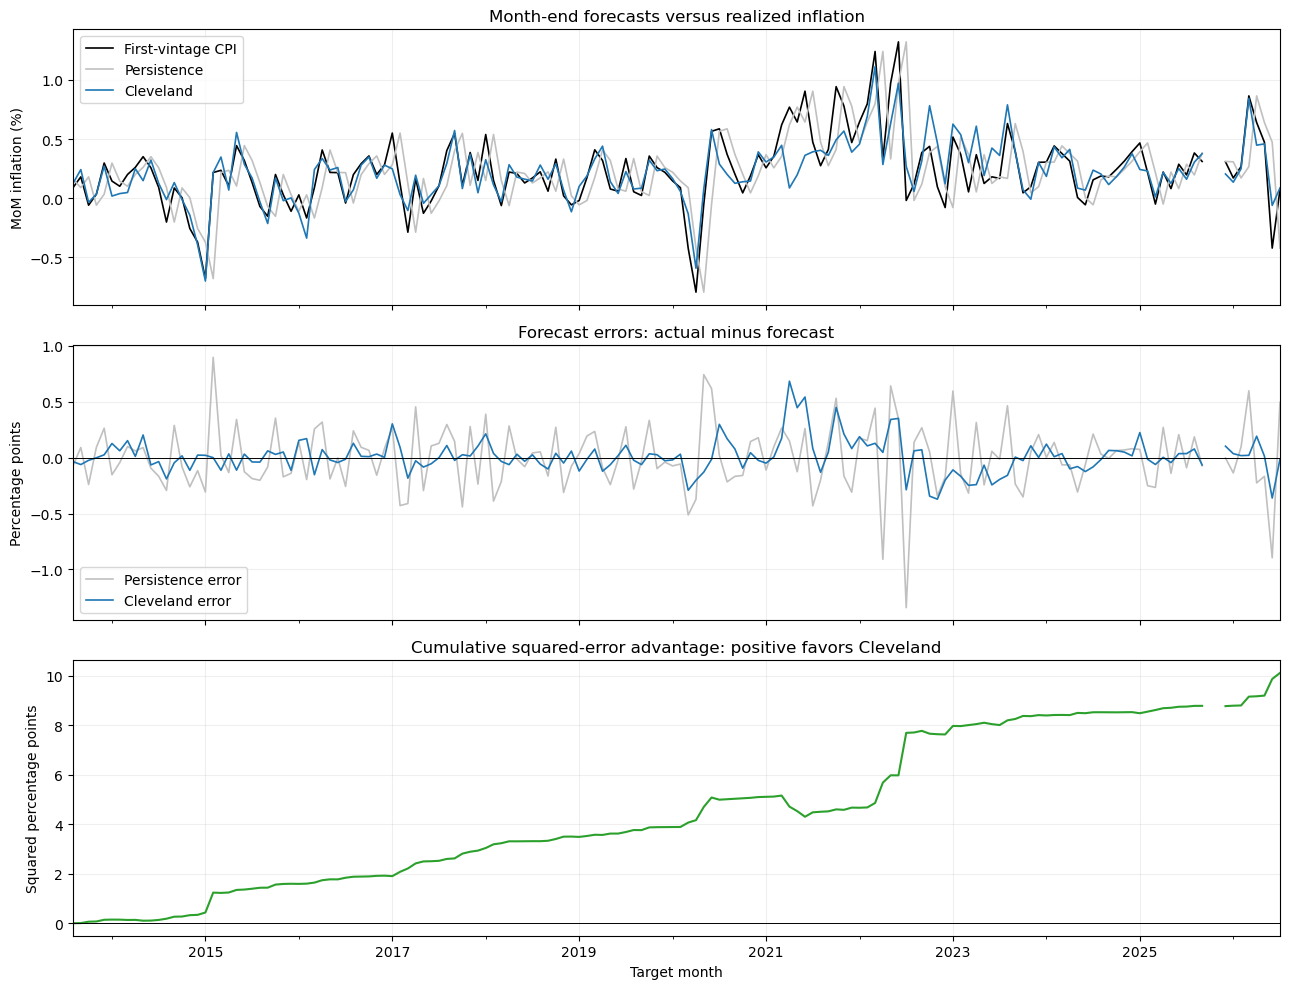

In [25]:
# 5. Inspection

fig, axes = plt.subplots(
    3, 1,
    figsize=(13, 10),
    sharex=True,
)

h2_eval[
    ["target_mom_first", "baseline_mom", "nowcast_mom"]
].rename(
    columns={
        "target_mom_first": "First-vintage CPI",
        "baseline_mom": "Persistence",
        "nowcast_mom": "Cleveland",
    }
).plot(
    ax=axes[0],
    color=["black", "silver", "tab:blue"],
    linewidth=1.2,
)

axes[0].set(
    title="Month-end forecasts versus realized inflation",
    ylabel="MoM inflation (%)",
)

h2_eval[
    ["error_persistence", "error_cleveland"]
].rename(
    columns={
        "error_persistence": "Persistence error",
        "error_cleveland": "Cleveland error",
    }
).plot(
    ax=axes[1],
    color=["silver", "tab:blue"],
    linewidth=1.2,
)

axes[1].axhline(0, color="black", linewidth=0.7)
axes[1].set(
    title="Forecast errors: actual minus forecast",
    ylabel="Percentage points",
)

# Accumulate observed contributions, leaving gaps at missing months.
h2_eval["loss_advantage"].cumsum().plot(
    ax=axes[2],
    color="tab:green",
)

axes[2].axhline(0, color="black", linewidth=0.7)
axes[2].set(
    title="Cumulative squared-error advantage: positive favors Cleveland",
    ylabel="Squared percentage points",
    xlabel="Target month",
)

for ax in axes:
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()